# Tugas Pertemuan 3

## BUSSINES UNDERSTANDING

### Latar Belakang dan Tujuan Penelitian
Penelitian ini bertujuan untuk menganalisis dan memodelkan kualitas udara di wilayah Kecamatan Masalembu, Kabupaten Sumenep, Madura. Observasi dilakukan menggunakan data spasio temporal berbasis satelit yang direkam selama rentang waktu satu tahun, terhitung sejak 24 Agustus 2025 hingga 24 Agustus 2026. Jendela waktu observasi ini menghasilkan 365 titik data harian (baris data) untuk setiap metrik kualitas udara. Tujuan akhir dari studi ini adalah memanfaatkan Time Series Feature Extraction Library (TSFEL) untuk mengekstraksi 68 fitur dari data deret waktu polutan, guna mengidentifikasi pola, karakteristik, dan anomali kualitas udara secara komprehensif.

### Ruang Lingkup dan Skenario Pengolahan Data
Proses pengumpulan data awal melibatkan ekstraksi lima parameter gas polutan, yaitu CO, NO2, O3, SO2, dan CH4. Pada fase Data Understanding dan prapemrosesan, seluruh variabel dari kelima polutan tersebut akan dievaluasi, ditransformasi, dan dibersihkan guna memastikan integritas serta validitas dataset secara keseluruhan.

Meskipun pembersihan data dilakukan pada seluruh parameter, batasan masalah pada penelitian ini menetapkan bahwa tahapan analisis lanjutan termasuk ekstraksi 68 fitur TSFEL dan pemodelan akhir hanya akan difokuskan pada variabel Karbon Monoksida (CO). Keempat polutan lainnya dipertahankan pada tahap awal sebagai pemenuhan spesifikasi penugasan sebelumnya dan untuk memberikan konteks kondisi atmosfer secara umum.

### Deskripsi Parameter Polutan
Variabel polutan yang tercakup dalam dataset observasi wilayah Masalembu meliputi:

- CO (Karbon Monoksida): Merupakan variabel target utama untuk ekstraksi fitur TSFEL. Gas ini umumnya mengindikasikan tingkat emisi dari pembakaran tidak sempurna dan aktivitas antropogenik.

- NO2 (Nitrogen Dioksida): Polutan primer yang bersumber dari aktivitas emisi bahan bakar, digunakan sebagai indikator tambahan tingkat polusi udara ambien.

- O3 (Ozon Permukaan): Polutan sekunder hasil reaksi fotokimia di atmosfer yang dipengaruhi oleh intensitas radiasi matahari dan gas prekursor di wilayah observasi.

- SO2 (Sulfur Dioksida): Parameter yang mengindikasikan keberadaan emisi berbasis sulfur, baik dari aktivitas pelayaran laut maupun sumber eksternal lainnya.

- CH4 (Metana): Emisi gas rumah kaca yang relevan untuk diamati pada wilayah kepulauan, sering kali berkaitan dengan proses dekomposisi organik alami maupun aktivitas domestik.

## DATA UNDERSTANDING

Pada tahap ini, kita akan mulai mengumpulkan data, mulai dari menarik data, kemudian kita akan mengupas data data tersebut, sehingga kita dapat memahami secara utuh data apa yang sedang kita gunakan saat ini.

### Mengumpulkan data

Kita akan menghubungkan copernicus dengan koordinat masalembu yang sudah kita ambil dari geojson.


In [9]:
import folium

# 1. Definisikan AOI (GeoJSON) Anda
aoi = {
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "properties": {},
      "geometry": {
        "type": "Polygon",
        "coordinates": [
          [
            [114.3944446, -5.5423607], [114.3939531, -5.5642533],
            [114.3950039, -5.5688155], [114.3988683, -5.5712245],
            [114.4149544, -5.5740227], [114.4222159, -5.5893249],
            [114.4349065, -5.5873077], [114.4477753, -5.5785626],
            [114.45452, -5.5647903],   [114.4512776, -5.5581054],
            [114.4525677, -5.547253],   [114.4431058, -5.5478645],
            [114.4401566, -5.5490876],  [114.4390507, -5.5448068],
            [114.4224617, -5.5461522],  [114.4138599, -5.5449292],
            [114.4129997, -5.5419938],  [114.4153345, -5.5364899],
            [114.4125082, -5.5322091],  [114.4123853, -5.5322091],
            [114.3944446, -5.5423607]
          ]
        ]
      }
    }
  ]
}

# 2. Titik tengah fokus peta
center_lat = -5.56
center_lon = 114.42

# 3. Buat peta dasar dengan FITUR INTERAKTIF YANG DIMATIKAN
m = folium.Map(
    location=[center_lat, center_lon], 
    zoom_start=13, 
    tiles="OpenStreetMap",
    zoom_control=False,          # Menghilangkan tombol [+] dan [-]
    scrollWheelZoom=False,       # Mematikan zoom pakai scroll mouse
    doubleClickZoom=False,       # Mematikan zoom pakai klik dua kali
    dragging=False,              # KUNCI UTAMA: Mematikan fitur geser (drag/pan)
    boxZoom=False,               # Mematikan fitur zoom kotak penyaring
    keyboard=False               # Mematikan navigasi via keyboard panah
)

# 4. Tambahkan poligon AOI Anda ke peta
folium.GeoJson(
    aoi,
    name="Statis AOI Layer",
    style_function=lambda feature: {
        "fillColor": "#ff4d4d",   
        "color": "#cc0000",       
        "weight": 3,              
        "fillOpacity": 0.4,       
    }
).add_to(m)

# 5. Simpan peta untuk Jupyter Book dan GitHub Pages
m.save("peta_statis_aoi.html")

# Tampilkan langsung di Jupyter Notebook
m


In [1]:
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


In [2]:
aoi = {
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "properties": {},
      "geometry": {
        "type": "Polygon",
        "coordinates": [
          [
            [
              114.3944446,
              -5.5423607
            ],
            [
              114.3939531,
              -5.5642533
            ],
            [
              114.3950039,
              -5.5688155
            ],
            [
              114.3988683,
              -5.5712245
            ],
            [
              114.4149544,
              -5.5740227
            ],
            [
              114.4222159,
              -5.5893249
            ],
            [
              114.4349065,
              -5.5873077
            ],
            [
              114.4477753,
              -5.5785626
            ],
            [
              114.45452,
              -5.5647903
            ],
            [
              114.4512776,
              -5.5581054
            ],
            [
              114.4525677,
              -5.547253
            ],
            [
              114.4431058,
              -5.5478645
            ],
            [
              114.4401566,
              -5.5490876
            ],
            [
              114.4390507,
              -5.5448068
            ],
            [
              114.4224617,
              -5.5461522
            ],
            [
              114.4138599,
              -5.5449292
            ],
            [
              114.4129997,
              -5.5419938
            ],
            [
              114.4153345,
              -5.5364899
            ],
            [
              114.4125082,
              -5.5322091
            ],
            [
              114.4123853,
              -5.5322091
            ],
            [
              114.3944446,
              -5.5423607
            ]
          ]
        ]
      }
    }
  ]
}

In [9]:
pollutants = ["CO", "NO2", "O3", "SO2", "CH4"]
datacubes = {}

for pol in pollutants:
    datacubes[pol] = connection.load_collection(
        "SENTINEL_5P_L2",
        temporal_extent=["2025-08-24", "2026-08-24"],
        spatial_extent={"west": 114.3939531, "south": -5.5893249, "east": 114.45452, "north": -5.5322091},
        bands=[pol],
    )

In [10]:
# Now aggregate by day to avoid having multiple data per day
# let's create a spatial aggregation to generate mean timeseries data

for pol in pollutants:
    datacubes[pol] = datacubes[pol].aggregate_temporal_period(reducer="mean", period="day")
    datacubes[pol] = datacubes[pol].aggregate_spatial(reducer="mean", geometries=aoi)

In [11]:
jobs = {}

for pol in pollutants:
    jobs[pol] = datacubes[pol].execute_batch(title=f"{pol} Masalembu", outputfile=f"{pol}_Masalembu.nc")

0:00:00 Job 'j-2609131625254a7198c85d7b9b1150c2': send 'start'
0:00:02 Job 'j-2609131625254a7198c85d7b9b1150c2': queued (progress 0%)
0:00:08 Job 'j-2609131625254a7198c85d7b9b1150c2': queued (progress 0%)
0:00:14 Job 'j-2609131625254a7198c85d7b9b1150c2': queued (progress 0%)
0:00:22 Job 'j-2609131625254a7198c85d7b9b1150c2': queued (progress 0%)
0:00:33 Job 'j-2609131625254a7198c85d7b9b1150c2': queued (progress 0%)
0:00:45 Job 'j-2609131625254a7198c85d7b9b1150c2': queued (progress 0%)
0:01:01 Job 'j-2609131625254a7198c85d7b9b1150c2': running (progress N/A)
0:01:21 Job 'j-2609131625254a7198c85d7b9b1150c2': running (progress N/A)
0:01:46 Job 'j-2609131625254a7198c85d7b9b1150c2': running (progress N/A)
0:02:16 Job 'j-2609131625254a7198c85d7b9b1150c2': running (progress N/A)
0:02:53 Job 'j-2609131625254a7198c85d7b9b1150c2': running (progress N/A)
0:03:40 Job 'j-2609131625254a7198c85d7b9b1150c2': running (progress N/A)
0:04:39 Job 'j-2609131625254a7198c85d7b9b1150c2': finished (progress 100%

### Membuat Grafik

Setelah data berhasil diambil, sesuai dengan contoh dari github, kita harus membuat grafik untuk kelimat data polutan tersebut.

In [6]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

pollutants = ["CO", "NO2", "O3", "SO2", "CH4"]
datasets = []

# Membaca kelima file .nc dan menyimpannya ke dalam list
for pol in pollutants:
    ds = xr.load_dataset(f"{pol}_Masalembu.nc")
    datasets.append(ds)

# Menggabungkan kelima data menjadi satu kesatuan berdasarkan waktu
merged_data = xr.merge(datasets)

df_masalembu = merged_data.to_dataframe().reset_index()
df_masalembu['t'] = pd.to_datetime(df_masalembu['t'])

df_masalembu = df_masalembu.set_index('t')

full_time_index = pd.date_range(start="2025-08-24", end="2026-08-23", freq="D")

# Sesuaikan data kita ke indeks waktu yang utuh tersebut
df_masalembu = df_masalembu.reindex(full_time_index)

# Kembalikan kolom waktu menjadi kolom biasa dan ubah namanya menjadi 't'
df_masalembu = df_masalembu.reset_index().rename(columns={'index': 't'})
df_masalembu.to_csv("Data_Masalembu_2526.csv", index=False, sep=";")

print(f"Total baris setelah diperbaiki: {len(df_masalembu)}")

Total baris setelah diperbaiki: 365


In [7]:
# Menghitung rata-rata bergerak per 30 hari untuk menghaluskan fluktuasi harian
merged_data = merged_data.rolling(t=30).mean()

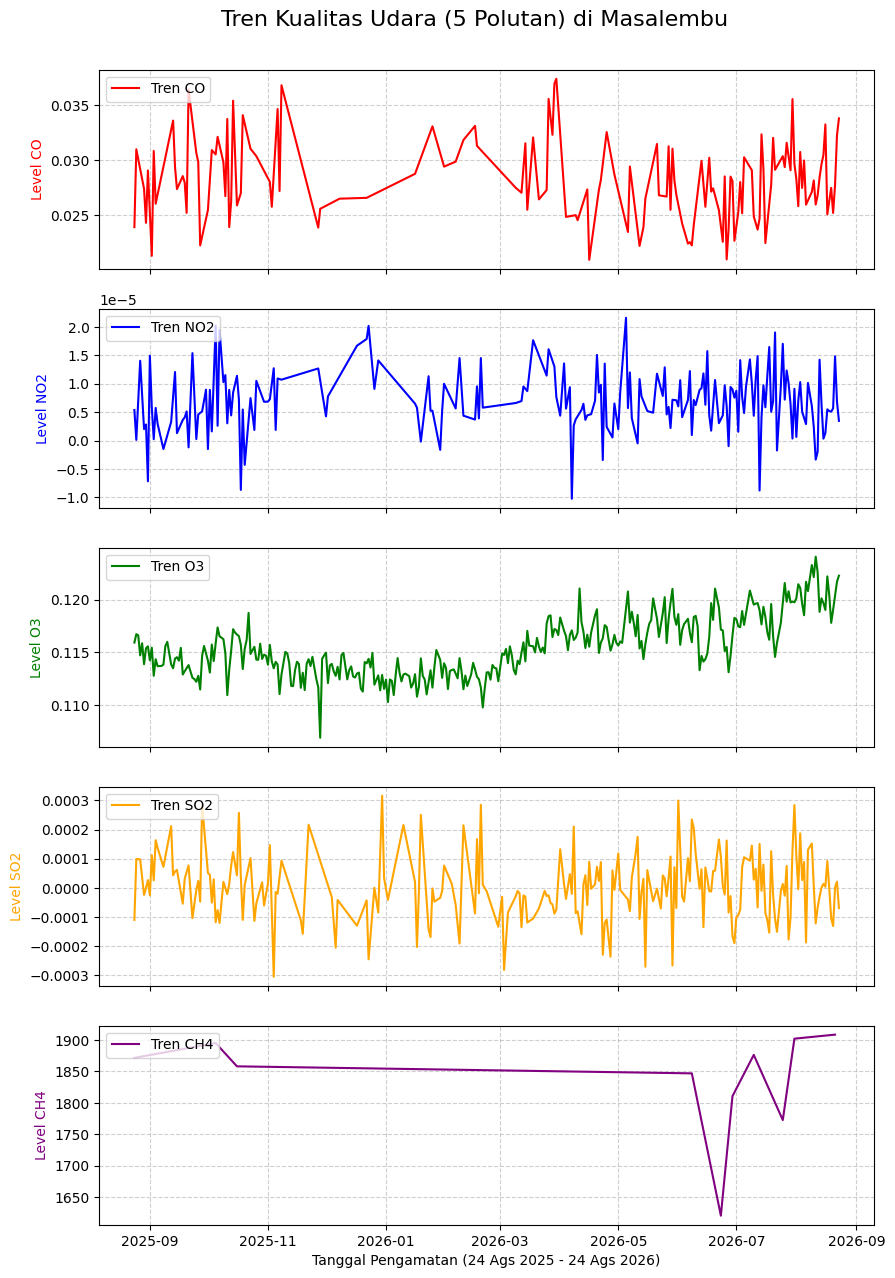

In [8]:
import matplotlib.pyplot as plt

unsur_polutan = ["CO", "NO2", "O3", "SO2", "CH4"]
warna_grafik = ["red", "blue", "green", "orange", "purple"]

# Membuat layout 5 baris grafik
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 15), sharex=True)

for i, (polutan, warna) in enumerate(zip(unsur_polutan, warna_grafik)):
    # Hanya mengambil hari di mana data polutan tersebut valid (tidak NaN)
    # Ini akan membuat Matplotlib otomatis menyambungkan garis antar titik
    data_udara = df_masalembu[['t', polutan]].dropna()
    
    axes[i].plot(data_udara['t'], data_udara[polutan], color=warna, label=f"Tren {polutan}")
    axes[i].set_ylabel(f"Level {polutan}", color=warna)
    axes[i].legend(loc="upper left")
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.xlabel("Tanggal Pengamatan (24 Ags 2025 - 24 Ags 2026)")
plt.suptitle("Tren Kualitas Udara (5 Polutan) di Masalembu", fontsize=16, y=0.92)

# Ekspor grafik menjadi gambar agar bisa dimasukkan ke laporan
plt.savefig("grafik_5_polutan.png", bbox_inches="tight")
plt.show()

### Memeriksa Data Polutan CO
Setelah data polutan dari koordinat yang kita miliki dengan rentang waktu yang telah kita tentukan di tarik, sekarang waktunya kita memeriksa data dari polutan CO

*Langkah PERTAMA*
Memeriksa jumlah baris dari Polutan CO dan dari rentang berapa sampai berapa diambil

In [10]:
from IPython.display import display

# Daftar polutan yang ingin dianalisis
daftar_polutan = ['CO', 'SO2', 'NO2', 'CH4']

for polutan in daftar_polutan:
    # 1. Mengambil hanya kolom Waktu ('t') dan Polutan saat ini dari loop
    data_polutan = df_masalembu[['t', polutan]]
    
    # 2. Menghitung total keseluruhan baris (tanpa menghapus NaN)
    total_baris = len(data_polutan)
    
    # 3. Mengidentifikasi rentang waktu awal dan akhir
    # (Pastikan kolom 't' sudah dalam format datetime sebelumnya)
    tanggal_awal = data_polutan['t'].min().strftime('%d %B %Y')
    tanggal_akhir = data_polutan['t'].max().strftime('%d %B %Y')
    
    # Menampilkan informasi
    print(f"--- INFO KESELURUHAN DATA {polutan} ---")
    print(f"Total Baris Keseluruhan: {total_baris} baris")
    print(f"Rentang Waktu: {tanggal_awal} s/d {tanggal_akhir}")
    print(f"\nContoh 5 Baris pertama data {polutan}:")
    
    # Menggunakan display() agar format tabel Pandas tetap rapi saat di dalam looping
    display(data_polutan.head())
    print("="*50 + "\n")

--- INFO KESELURUHAN DATA CO ---
Total Baris Keseluruhan: 365 baris
Rentang Waktu: 24 August 2025 s/d 23 August 2026

Contoh 5 Baris pertama data CO:


,t,CO
0,2025-08-24,0.023889
1,2025-08-25,0.030957
2,2025-08-26,NaN
3,2025-08-27,NaN
4,2025-08-28,NaN



--- INFO KESELURUHAN DATA SO2 ---
Total Baris Keseluruhan: 365 baris
Rentang Waktu: 24 August 2025 s/d 23 August 2026

Contoh 5 Baris pertama data SO2:


,t,SO2
0,2025-08-24,-0.000111
1,2025-08-25,0.000099
2,2025-08-26,NaN
3,2025-08-27,0.000097
4,2025-08-28,NaN



--- INFO KESELURUHAN DATA NO2 ---
Total Baris Keseluruhan: 365 baris
Rentang Waktu: 24 August 2025 s/d 23 August 2026

Contoh 5 Baris pertama data NO2:


,t,NO2
0,2025-08-24,5.375151e-06
1,2025-08-25,1.228439e-07
2,2025-08-26,NaN
3,2025-08-27,1.402013e-05
4,2025-08-28,NaN



--- INFO KESELURUHAN DATA CH4 ---
Total Baris Keseluruhan: 365 baris
Rentang Waktu: 24 August 2025 s/d 23 August 2026

Contoh 5 Baris pertama data CH4:


,t,CH4
0,2025-08-24,1871.452026
1,2025-08-25,NaN
2,2025-08-26,NaN
3,2025-08-27,NaN
4,2025-08-28,NaN


*Langkah KEDUA*
Kita akan mengecek missing values dan Outliernya

In [11]:
daftar_polutan = ['CO', 'SO2', 'NO2', 'CH4']

for polutan in daftar_polutan:
    # Menghitung total baris dari dataframe utama
    total_baris = len(df_masalembu)
    
    # Menghitung jumlah missing values sesuai nama polutan pada iterasi saat ini
    missing_val = df_masalembu[polutan].isna().sum()
    persentase_missing = (missing_val / total_baris) * 100

    print(f"=== LAPORAN MISSING VALUES {polutan} ===")
    print(f"Total Baris Data : {total_baris}")
    print(f"Jumlah Missing   : {missing_val}")
    print(f"Persentase       : {persentase_missing:.2f}%")
    print("=================================\n")

=== LAPORAN MISSING VALUES CO ===
Total Baris Data : 365
Jumlah Missing   : 225
Persentase       : 61.64%

=== LAPORAN MISSING VALUES SO2 ===
Total Baris Data : 365
Jumlah Missing   : 132
Persentase       : 36.16%

=== LAPORAN MISSING VALUES NO2 ===
Total Baris Data : 365
Jumlah Missing   : 165
Persentase       : 45.21%

=== LAPORAN MISSING VALUES CH4 ===
Total Baris Data : 365
Jumlah Missing   : 355
Persentase       : 97.26%



## DATA PREPARATION

#### MENGATASI MISSING VALUE
Berdasarkan pengecekan sebelumnya, data gas Karbon Monoksida (CO) memiliki tingkat kekosongan (missing values) yang cukup tinggi, yaitu sebesar 61.64% (225 hari dari total 365 hari observasi). Kekosongan ini merupakan hal yang wajar dalam penginderaan jauh (remote sensing) satelit Sentinel-5P, terutama di wilayah kepulauan maritim seperti Masalembu, di mana pantulan permukaan laut yang rendah dan tingginya intensitas tutupan awan sering kali menghalangi sensor satelit untuk menangkap data dengan valid.

Karena metode ekstraksi fitur menggunakan pustaka TSFEL (Time Series Feature Extraction Library) mewajibkan deret waktu yang utuh 100% tanpa ada nilai kosong (NaN), kita perlu melakukan pengisian data atau imputation.

Pada tahap ini, kita menggunakan metode kombinasi:

Linear Interpolation (Interpolasi Linier): Metode utama yang digunakan untuk menambal data kosong di tengah deret waktu. Algoritma ini akan memperkirakan nilai yang hilang dengan cara menarik garis lurus matematis secara proporsional di antara dua titik data valid yang mengapitnya. Hal ini menjaga agar tren kenaikan atau penurunan gas CO tetap terlihat logis dan natural.

Forward Fill (ffill) & Backward Fill (bfill): Digunakan sebagai metode pendukung untuk menambal nilai kosong yang berada di ujung paling awal atau paling akhir dari rentang waktu, di mana interpolasi linier tidak bisa bekerja karena tidak ada titik batas (boundary point).

Berikut adalah implementasi kode untuk melakukan imputation tersebut beserta visualisasi perbandingan data sebelum dan sesudahnya:

=== PROSES IMPUTASI CO ===
Jumlah Missing CO setelah imputasi: 0


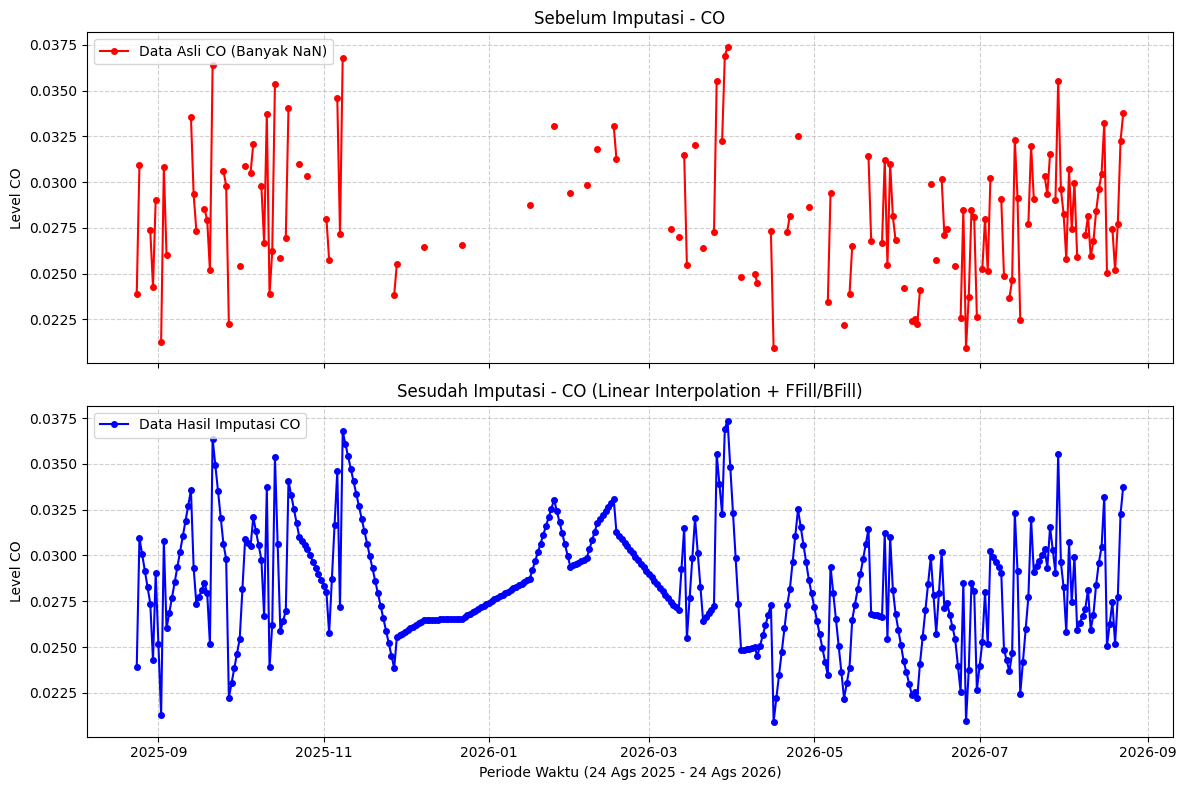



=== PROSES IMPUTASI SO2 ===
Jumlah Missing SO2 setelah imputasi: 0


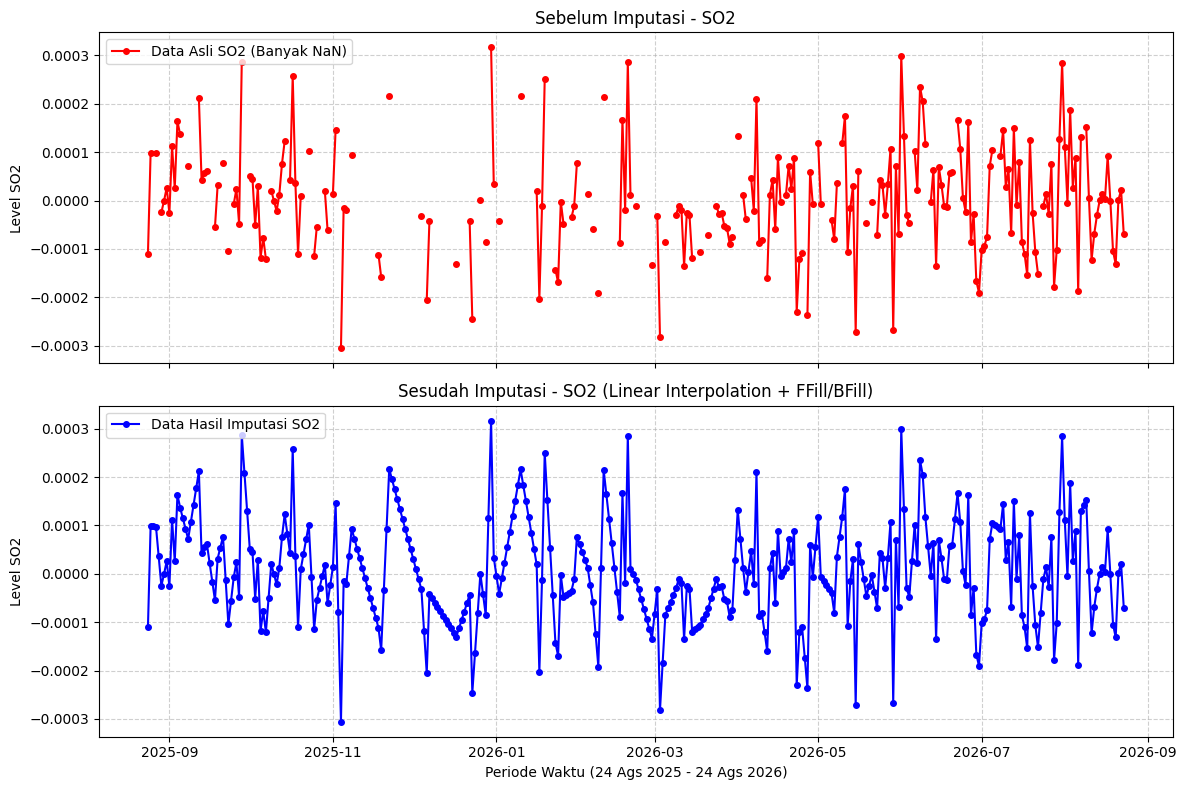



=== PROSES IMPUTASI NO2 ===
Jumlah Missing NO2 setelah imputasi: 0


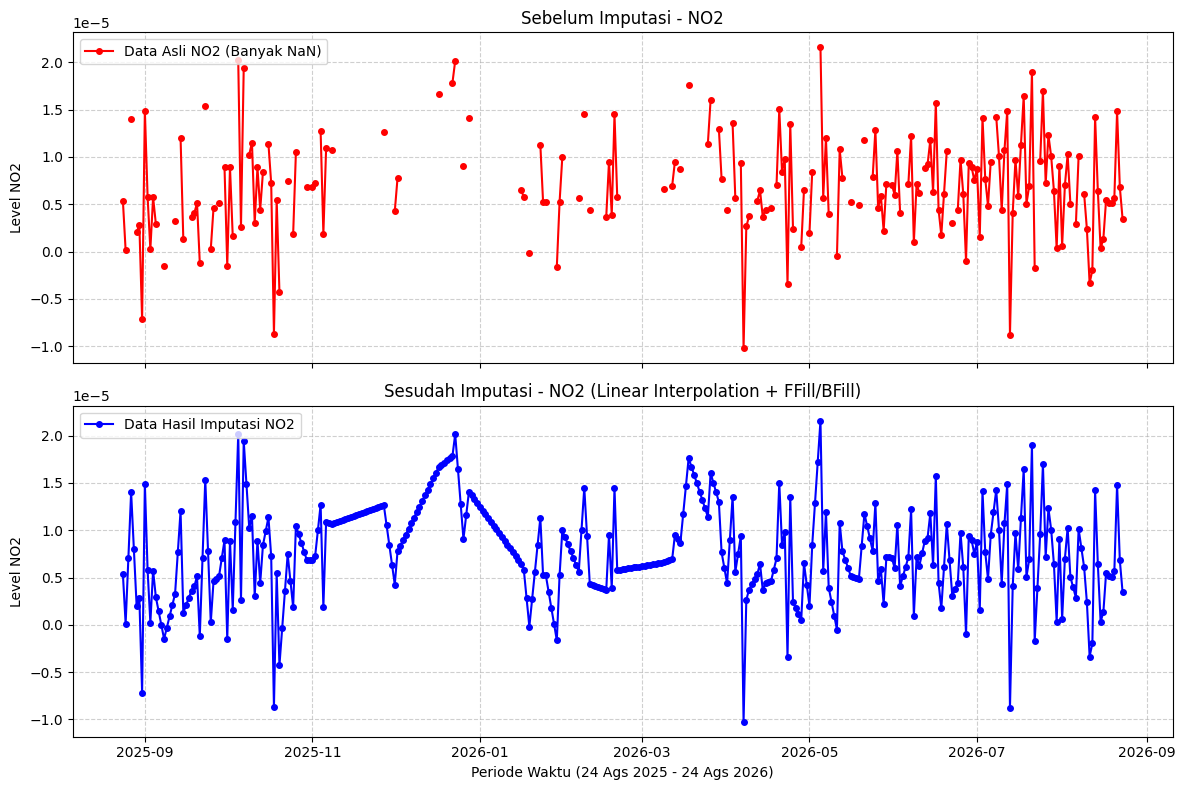



=== PROSES IMPUTASI CH4 ===
Jumlah Missing CH4 setelah imputasi: 0


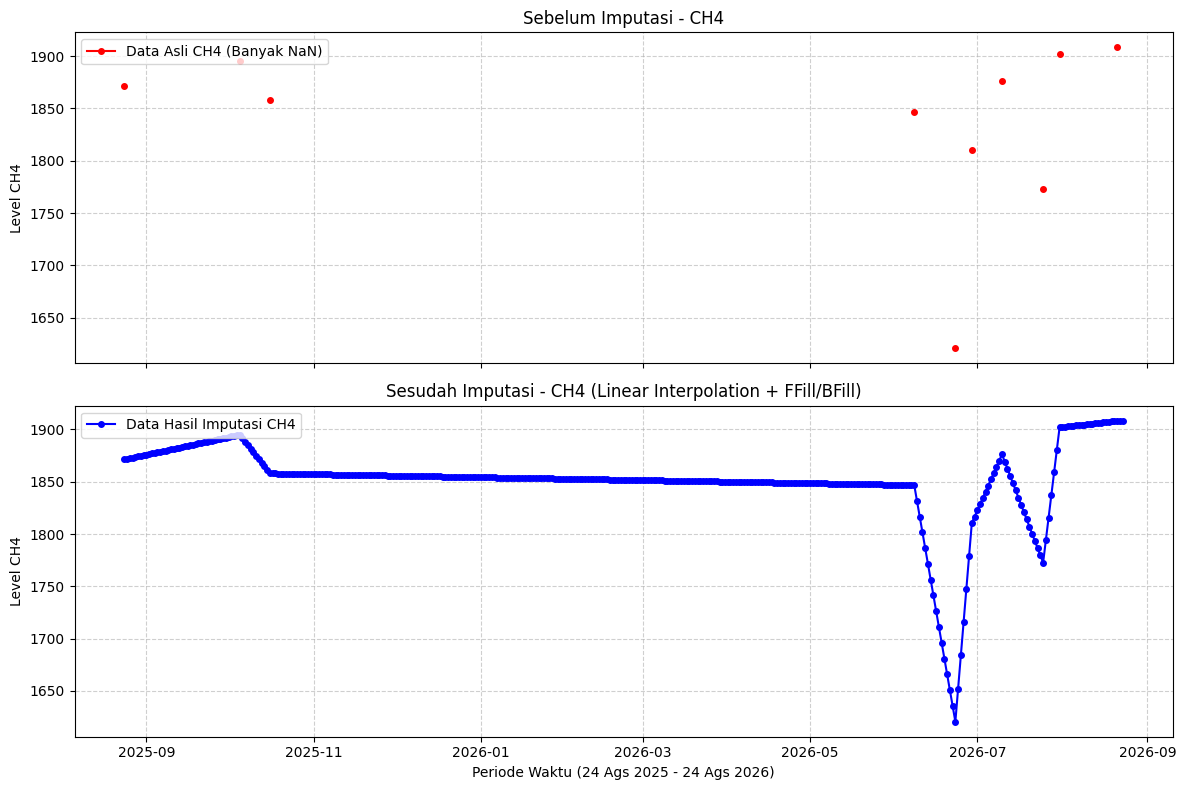

In [12]:
import matplotlib.pyplot as plt

daftar_polutan = ['CO', 'SO2', 'NO2', 'CH4']

for polutan in daftar_polutan:
    # Mengambil subset data untuk polutan saat ini agar aman
    data_polutan = df_masalembu[['t', polutan]].copy()
    
    # 1. Salin data agar data mentah tidak tertimpa
    data_polutan_imputed = data_polutan.copy()

    # 2. Proses Imputasi Utama: Linear Interpolation 
    data_polutan_imputed[polutan] = data_polutan_imputed[polutan].interpolate(method='linear')

    # 3. Proses Imputasi Tepi: Forward Fill & Backward Fill
    data_polutan_imputed[polutan] = data_polutan_imputed[polutan].ffill().bfill()
    
    # Memasukkan kembali hasil imputasi ke dataframe utama agar tersimpan
    df_masalembu[polutan] = data_polutan_imputed[polutan]

    # Cek hasil akhir
    missing_setelah = data_polutan_imputed[polutan].isna().sum()
    print(f"=== PROSES IMPUTASI {polutan} ===")
    print(f"Jumlah Missing {polutan} setelah imputasi: {missing_setelah}")

    # 4. Visualisasi Perbandingan
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), dpi=100, sharex=True)

    # Grafik Atas: Sebelum Imputasi (Terputus-putus)
    axes[0].plot(data_polutan['t'], data_polutan[polutan], color='red', marker='o', markersize=4, label=f'Data Asli {polutan} (Banyak NaN)')
    axes[0].set_title(f'Sebelum Imputasi - {polutan}', fontsize=12)
    axes[0].set_ylabel(f'Level {polutan}')
    axes[0].legend(loc="upper left")
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # Grafik Bawah: Sesudah Imputasi (Tersambung penuh)
    axes[1].plot(data_polutan_imputed['t'], data_polutan_imputed[polutan], color='blue', marker='o', markersize=4, label=f'Data Hasil Imputasi {polutan}')
    axes[1].set_title(f'Sesudah Imputasi - {polutan} (Linear Interpolation + FFill/BFill)', fontsize=12)
    axes[1].set_ylabel(f'Level {polutan}')
    axes[1].set_xlabel('Periode Waktu (24 Ags 2025 - 24 Ags 2026)')
    axes[1].legend(loc="upper left")
    axes[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()
    print("\n") # Memberikan jarak antar grafik polutan

In [13]:
from IPython.display import display
import pandas as pd

daftar_polutan = ['CO', 'SO2', 'NO2', 'CH4']

for polutan in daftar_polutan:
    # Mengambil data polutan yang sudah bersih dari dataframe utama
    data_polutan_imputed = df_masalembu[['t', polutan]]
    
    # Penamaan file dinamis menyesuaikan nama polutan
    nama_file = f"Data_{polutan}_Masalembu_Imputed.csv"
    
    # Menyimpan data yang sudah bersih dan terisi penuh ke file CSV
    data_polutan_imputed.to_csv(nama_file, index=False, sep=";")
    print(f"Data berhasil disimpan menjadi '{nama_file}'")

    # 1. Membaca file CSV hasil imputasi dengan separator ';'
    df_loaded = pd.read_csv(nama_file, sep=";")

    # Konversi kembali kolom waktu ke datetime
    df_loaded['t'] = pd.to_datetime(df_loaded['t'])

    # 2. Pengecekan ulang missing values pada kolom polutan saat ini
    total_baris = len(df_loaded)
    missing_val = df_loaded[polutan].isna().sum()
    persentase_missing = (missing_val / total_baris) * 100

    print(f"=== VERIFIKASI MISSING VALUES {polutan} (DARI FILE CSV) ===")
    print(f"Total Baris Data : {total_baris}")
    print(f"Jumlah Missing   : {missing_val}")
    print(f"Persentase       : {persentase_missing:.2f}%")
    print("==================================================")

    # Menampilkan 5 baris pertama menggunakan display() agar tabel muncul berulang
    display(df_loaded.head())
    print("\n")

Data berhasil disimpan menjadi 'Data_CO_Masalembu_Imputed.csv'
=== VERIFIKASI MISSING VALUES CO (DARI FILE CSV) ===
Total Baris Data : 365
Jumlah Missing   : 0
Persentase       : 0.00%


,t,CO
0,2025-08-24,0.023889
1,2025-08-25,0.030957
2,2025-08-26,0.030060
3,2025-08-27,0.029163
4,2025-08-28,0.028265




Data berhasil disimpan menjadi 'Data_SO2_Masalembu_Imputed.csv'
=== VERIFIKASI MISSING VALUES SO2 (DARI FILE CSV) ===
Total Baris Data : 365
Jumlah Missing   : 0
Persentase       : 0.00%


,t,SO2
0,2025-08-24,-0.000111
1,2025-08-25,0.000099
2,2025-08-26,0.000098
3,2025-08-27,0.000097
4,2025-08-28,0.000036




Data berhasil disimpan menjadi 'Data_NO2_Masalembu_Imputed.csv'
=== VERIFIKASI MISSING VALUES NO2 (DARI FILE CSV) ===
Total Baris Data : 365
Jumlah Missing   : 0
Persentase       : 0.00%


,t,NO2
0,2025-08-24,5.375151e-06
1,2025-08-25,1.228439e-07
2,2025-08-26,7.071485e-06
3,2025-08-27,1.402013e-05
4,2025-08-28,8.019186e-06




Data berhasil disimpan menjadi 'Data_CH4_Masalembu_Imputed.csv'
=== VERIFIKASI MISSING VALUES CH4 (DARI FILE CSV) ===
Total Baris Data : 365
Jumlah Missing   : 0
Persentase       : 0.00%


,t,CH4
0,2025-08-24,1871.452026
1,2025-08-25,1872.012277
2,2025-08-26,1872.572527
3,2025-08-27,1873.132778
4,2025-08-28,1873.693028


#### IDENTIFIKASI OUTLIER

Pencilan (outlier) mendefinisikan titik data yang menyimpang secara ekstrem dari tren atau distribusi umum di sekitarnya. 

Pada data deret waktu hasil penginderaan jauh (remote sensing), pencilan lazimnya dipicu oleh galat sensor instrumen, anomali reflektansi permukaan atau awan tipis yang lolos filter awal, maupun fluktuasi atmosfer sesaat. Bagi pipeline Time Series Feature Extraction Library (TSFEL), keberadaan pencilan sangat merusak karena metrik statistik dasar (seperti standar deviasi, variansi, energi, nilai maksimum/minimum) bersifat sangat sensitif terhadap nilai ekstrem, sehingga distorsi kecil pun dapat mencemari representasi fitur secara keseluruhan.

Alih-alih menghapus baris observasi yang berisiko merusak struktur kelengkapan temporal 365 hari, strategi penanganan dilakukan dengan teknik masking nilai ekstrem menjadi NaN diikuti rekonstruksi sinyal melalui tahapan prosedural berikut:
- Identifikasi ambang batas anomali menggunakan metode Interquartile Range (IQR) untuk menghitung kuartil pertama ($Q_1$), kuartil ketiga ($Q_3$), batas bawah ($Q_1 - 1.5 \times IQR$), dan batas atas ($Q_3 + 1.5 \times IQR$).
- Konversi nilai data yang berada di luar rentang batas wajar menjadi NaN (masking).
- Pengisian kembali celah data hasil masking menggunakan kombinasi linear interpolation, forward fill (ffill), dan backward fill (bfill) untuk menjaga kontinuitas tren yang valid bagi TSFEL.

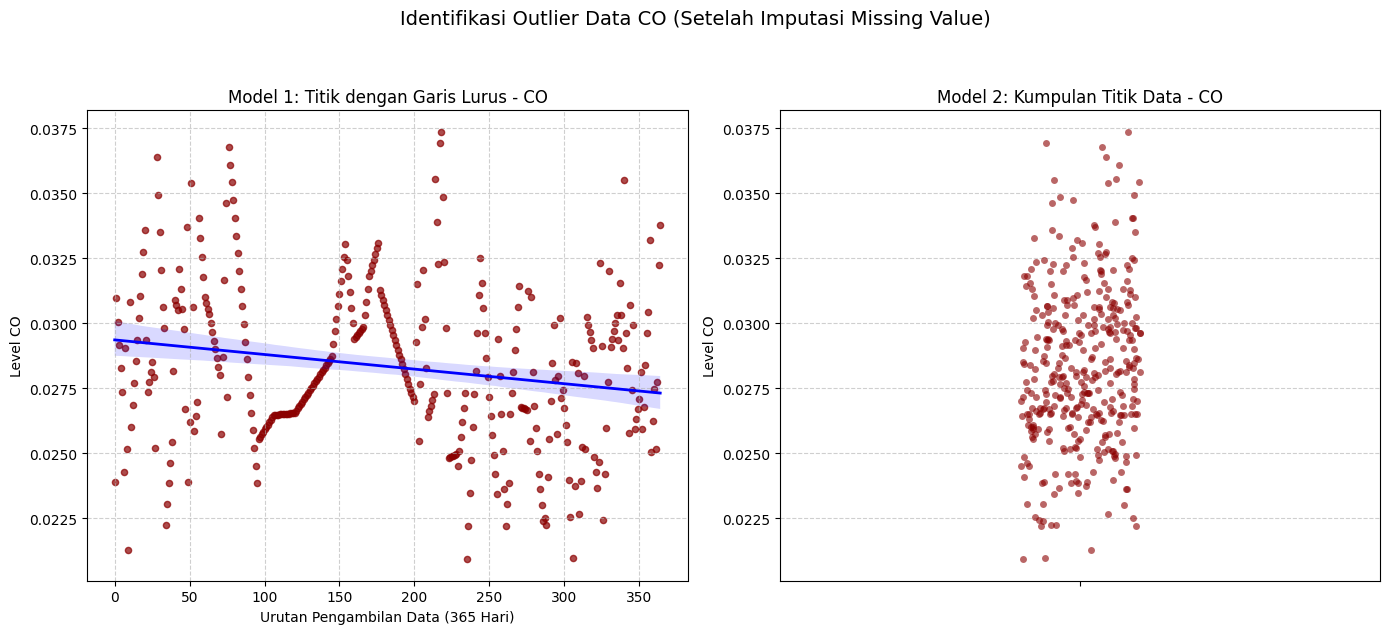

--------------------------------------------------------------------------------



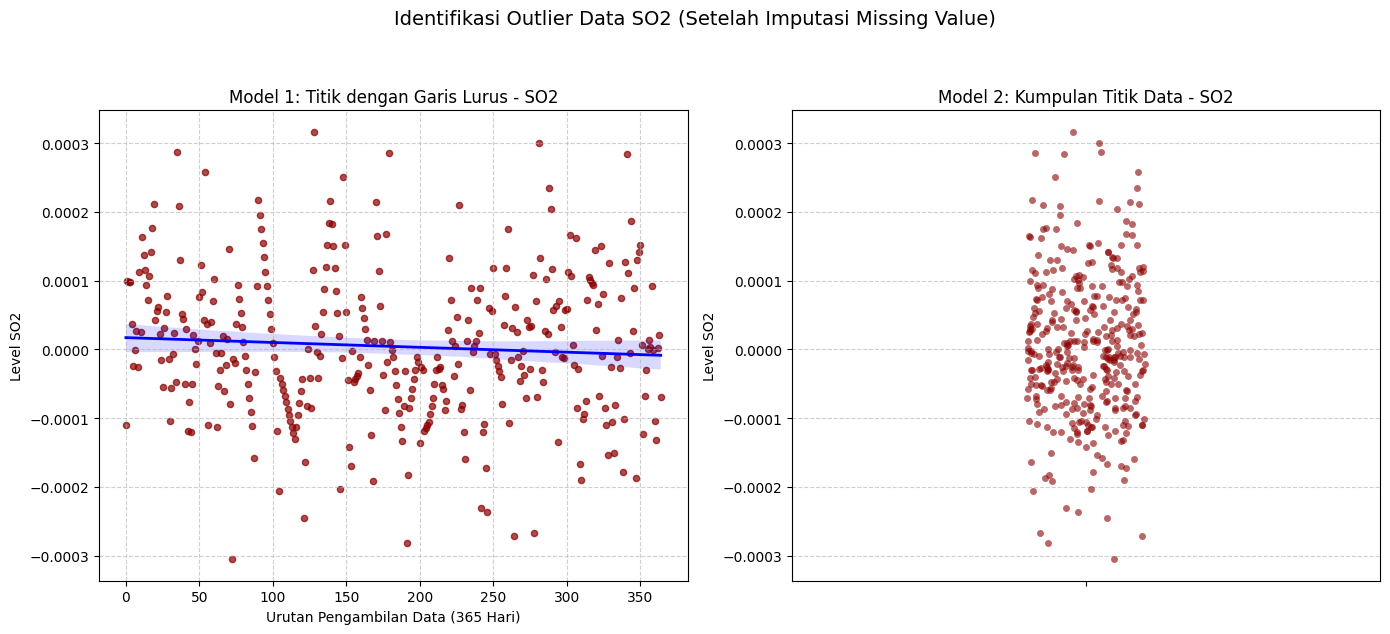

--------------------------------------------------------------------------------



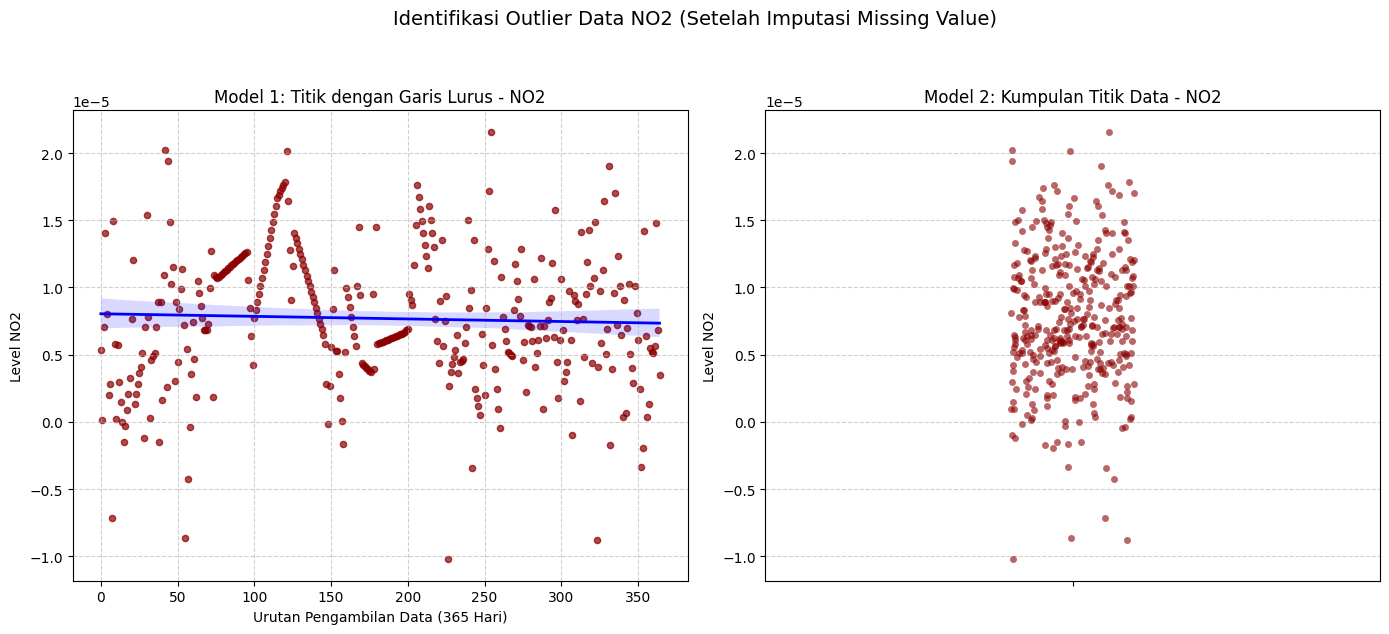

--------------------------------------------------------------------------------



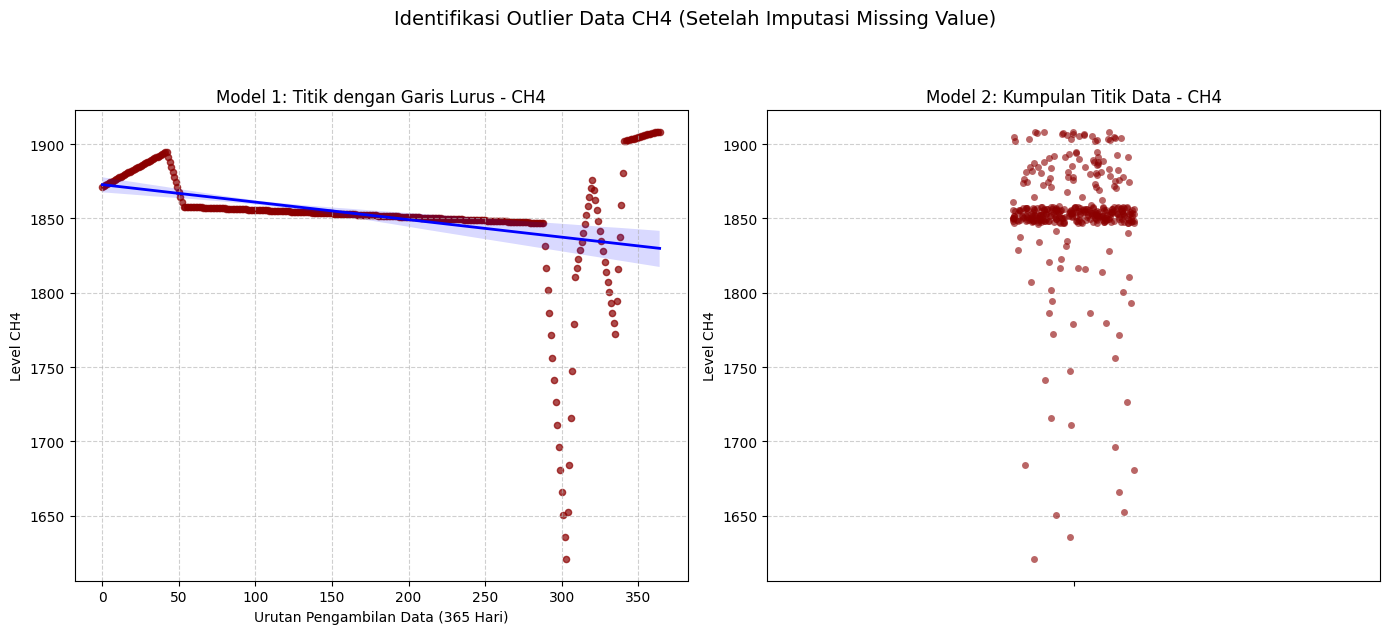

--------------------------------------------------------------------------------



In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

daftar_polutan = ['CO', 'SO2', 'NO2', 'CH4']

for polutan in daftar_polutan:
    # 1. Membaca file CSV dinamis menyesuaikan iterasi
    nama_file = f"Data_{polutan}_Masalembu_Imputed.csv"
    df_loaded = pd.read_csv(nama_file, sep=";")
    df_loaded['t'] = pd.to_datetime(df_loaded['t'])

    # Karena data sudah bersih dari NaN (utuh 365 hari), langsung salin ke variabel analisis
    data_imputed_clean = df_loaded.copy()

    # Membuat kolom urutan numerik (0, 1, 2, ...) sebagai sumbu X untuk garis lurus
    data_imputed_clean['urutan'] = np.arange(len(data_imputed_clean))

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6), dpi=100)

    # Model 1: Titik dengan Garis Lurus (Regresi Linear)
    sns.regplot(
        x='urutan', 
        y=polutan, # Memanggil nama kolom sesuai polutan
        data=data_imputed_clean, 
        ax=axes[0], 
        scatter_kws={'color': 'darkred', 's': 20, 'alpha': 0.7}, 
        line_kws={'color': 'blue', 'linewidth': 2}
    )
    axes[0].set_title(f'Model 1: Titik dengan Garis Lurus - {polutan}', fontsize=12)
    axes[0].set_xlabel('Urutan Pengambilan Data (365 Hari)')
    axes[0].set_ylabel(f'Level {polutan}')
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # Model 2: Kumpulan Titik Murni (Strip Plot)
    sns.stripplot(
        y=data_imputed_clean[polutan], # Memanggil nama kolom sesuai polutan
        ax=axes[1], 
        color='darkred', 
        alpha=0.6, 
        jitter=True, 
        size=5
    )
    axes[1].set_title(f'Model 2: Kumpulan Titik Data - {polutan}', fontsize=12)
    axes[1].set_ylabel(f'Level {polutan}')
    axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)

    plt.suptitle(f"Identifikasi Outlier Data {polutan} (Setelah Imputasi Missing Value)", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()
    print("-" * 80 + "\n")

#### MEMERIKSA OUTLIER MENGGUNAKAN METODE IQR (Interquartil Range)

In [15]:
daftar_polutan = ['CO', 'SO2', 'NO2', 'CH4']

for polutan in daftar_polutan:
    # 1. Membaca kembali file CSV yang sesuai jika belum termuat di memory secara independen
    nama_file = f"Data_{polutan}_Masalembu_Imputed.csv"
    data_imputed_clean = pd.read_csv(nama_file, sep=";")
    data_imputed_clean['t'] = pd.to_datetime(data_imputed_clean['t'])
    data_imputed_clean['urutan'] = np.arange(len(data_imputed_clean))
    
    # 2. Hitung kuartil dan IQR dari data bersih imputasi untuk polutan saat ini
    Q1 = data_imputed_clean[polutan].quantile(0.25)
    Q3 = data_imputed_clean[polutan].quantile(0.75)
    IQR = Q3 - Q1

    # 3. Tentukan ambang batas
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    # 4. Identifikasi/filter baris outlier
    outlier_mask = (data_imputed_clean[polutan] < lower_bound) | (data_imputed_clean[polutan] > upper_bound)
    df_outliers = data_imputed_clean[outlier_mask]

    print(f"=== IDENTIFIKASI OUTLIER {polutan} ===")
    print(f"Batas Bawah : {lower_bound:.6f}")
    print(f"Batas Atas  : {upper_bound:.6f}")
    print(f"Jumlah Outlier Ditemukan: {len(df_outliers)} baris\n")
    print(f"Daftar Baris Outlier {polutan}:")
    
    # Menampilkan hasil jika ada outlier, jika tidak, berikan pesan alternatif
    if len(df_outliers) > 0:
        display(df_outliers[['t', 'urutan', polutan]])
    else:
        print(f"Tidak ada outlier yang ditemukan pada data {polutan}.")
        
    print("-" * 50 + "\n")

=== IDENTIFIKASI OUTLIER CO ===
Batas Bawah : 0.020550
Batas Atas  : 0.036196
Jumlah Outlier Ditemukan: 4 baris

Daftar Baris Outlier CO:


,t,urutan,CO
28,2025-09-21,28,0.036376
76,2025-11-08,76,0.036770
217,2026-03-29,217,0.036915
218,2026-03-30,218,0.037360


--------------------------------------------------

=== IDENTIFIKASI OUTLIER SO2 ===
Batas Bawah : -0.000276
Batas Atas  : 0.000280
Jumlah Outlier Ditemukan: 7 baris

Daftar Baris Outlier SO2:


,t,urutan,SO2
35,2025-09-28,35,0.000287
72,2025-11-04,72,-0.000306
128,2025-12-30,128,0.000316
179,2026-02-19,179,0.000285
191,2026-03-03,191,-0.000282
281,2026-06-01,281,0.000300
341,2026-07-31,341,0.000284


--------------------------------------------------

=== IDENTIFIKASI OUTLIER NO2 ===
Batas Bawah : -0.000005
Batas Atas  : 0.000021
Jumlah Outlier Ditemukan: 5 baris

Daftar Baris Outlier NO2:


,t,urutan,NO2
7,2025-08-31,7,-0.000007
55,2025-10-18,55,-0.000009
226,2026-04-07,226,-0.000010
254,2026-05-05,254,0.000022
323,2026-07-13,323,-0.000009


--------------------------------------------------

=== IDENTIFIKASI OUTLIER CH4 ===
Batas Bawah : 1836.340765
Batas Atas  : 1870.539942
Jumlah Outlier Ditemukan: 113 baris

Daftar Baris Outlier CH4:


,t,urutan,CH4
0,2025-08-24,0,1871.452026
1,2025-08-25,1,1872.012277
2,2025-08-26,2,1872.572527
3,2025-08-27,3,1873.132778
4,2025-08-28,4,1873.693028
...,...,...,...
360,2026-08-19,360,1907.785348
361,2026-08-20,361,1908.090733
362,2026-08-21,362,1908.396118
363,2026-08-22,363,1908.396118


--------------------------------------------------



#### PENANGANAN OUTLIER MENGGUNAKAN METODE IMPUTATION



==================== MEMPROSES CO ====================
Batas Bawah IQR  : 0.020550
Batas Atas IQR   : 0.036196
Jumlah Outlier   : 4 baris

=== TABEL PERBANDINGAN NILAI OUTLIER CO (SEBELUM VS SESUDAH) ===


,t,sebelum (ekstrem),sesudah (hasil interpolasi)
28,2025-09-21,0.036376,0.030061
76,2025-11-08,0.036770,0.031631
217,2026-03-29,0.036915,0.033131
218,2026-03-30,0.037360,0.033991


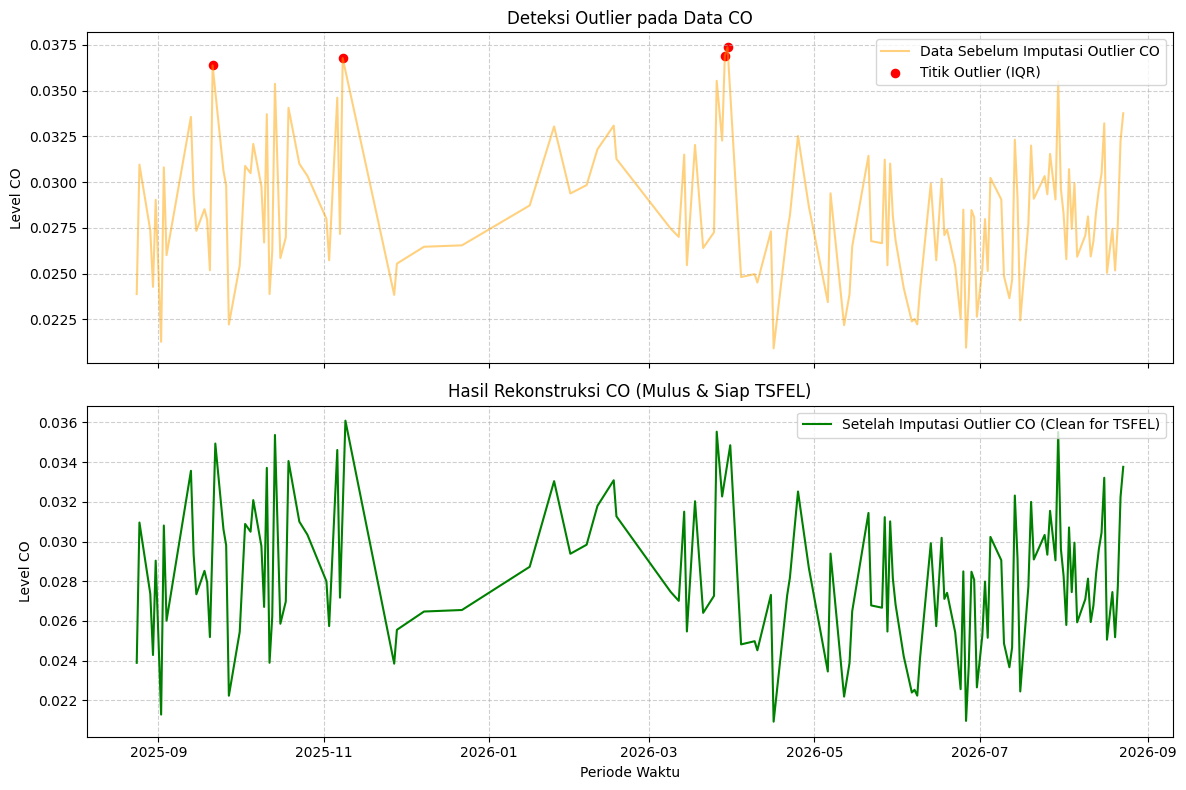

Dataset final tersimpan sebagai 'Data_CO_Masalembu_Ready_TSFEL.csv'



==================== MEMPROSES SO2 ====================
Batas Bawah IQR  : -0.000276
Batas Atas IQR   : 0.000280
Jumlah Outlier   : 7 baris

=== TABEL PERBANDINGAN NILAI OUTLIER SO2 (SEBELUM VS SESUDAH) ===


,t,sebelum (ekstrem),sesudah (hasil interpolasi)
35,2025-09-28,0.000287,0.000080
72,2025-11-04,-0.000306,-0.000047
128,2025-12-30,0.000316,0.000075
179,2026-02-19,0.000285,-0.000004
191,2026-03-03,-0.000282,-0.000107
281,2026-06-01,0.000300,0.000032
341,2026-07-31,0.000284,0.000119


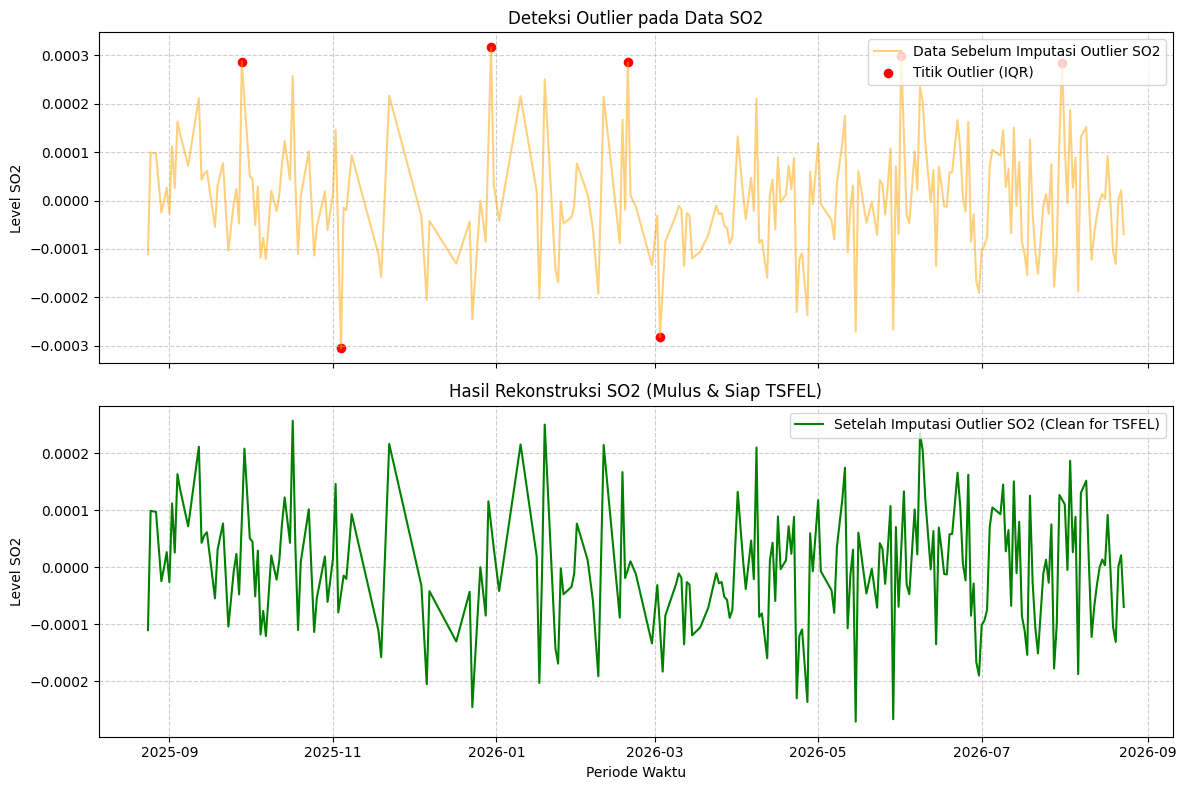

Dataset final tersimpan sebagai 'Data_SO2_Masalembu_Ready_TSFEL.csv'



==================== MEMPROSES NO2 ====================
Batas Bawah IQR  : -0.000005
Batas Atas IQR   : 0.000021
Jumlah Outlier   : 5 baris

=== TABEL PERBANDINGAN NILAI OUTLIER NO2 (SEBELUM VS SESUDAH) ===


,t,sebelum (ekstrem),sesudah (hasil interpolasi)
7,2025-08-31,-0.000007,0.000009
55,2025-10-18,-0.000009,0.000006
226,2026-04-07,-0.000010,0.000006
254,2026-05-05,0.000022,0.000011
323,2026-07-13,-0.000009,0.000009


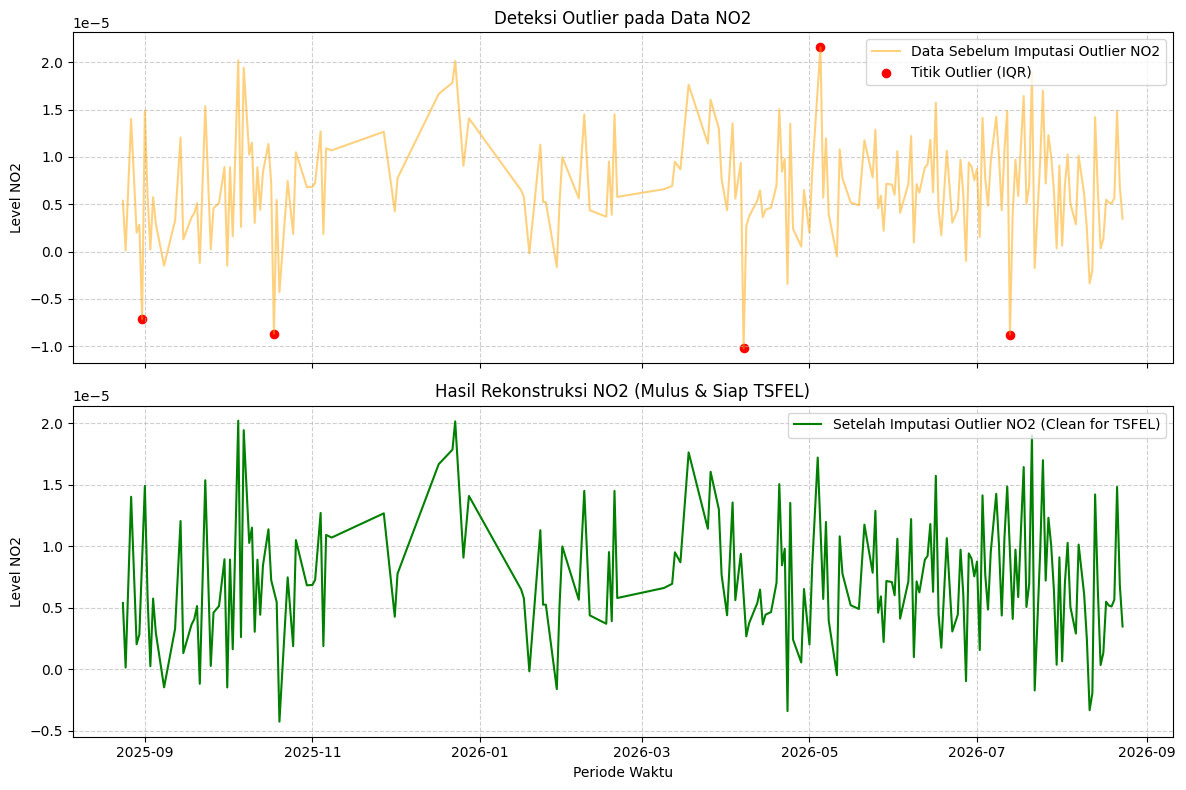

Dataset final tersimpan sebagai 'Data_NO2_Masalembu_Ready_TSFEL.csv'



==================== MEMPROSES CH4 ====================
Batas Bawah IQR  : 1836.340765
Batas Atas IQR   : 1870.539942
Jumlah Outlier   : 113 baris

=== TABEL PERBANDINGAN NILAI OUTLIER CH4 (SEBELUM VS SESUDAH) ===


,t,sebelum (ekstrem),sesudah (hasil interpolasi)
0,2025-08-24,1871.452026,1868.086326
1,2025-08-25,1872.012277,1868.086326
2,2025-08-26,1872.572527,1868.086326
3,2025-08-27,1873.132778,1868.086326
4,2025-08-28,1873.693028,1868.086326
...,...,...,...
360,2026-08-19,1907.785348,1858.848796
361,2026-08-20,1908.090733,1858.848796
362,2026-08-21,1908.396118,1858.848796
363,2026-08-22,1908.396118,1858.848796


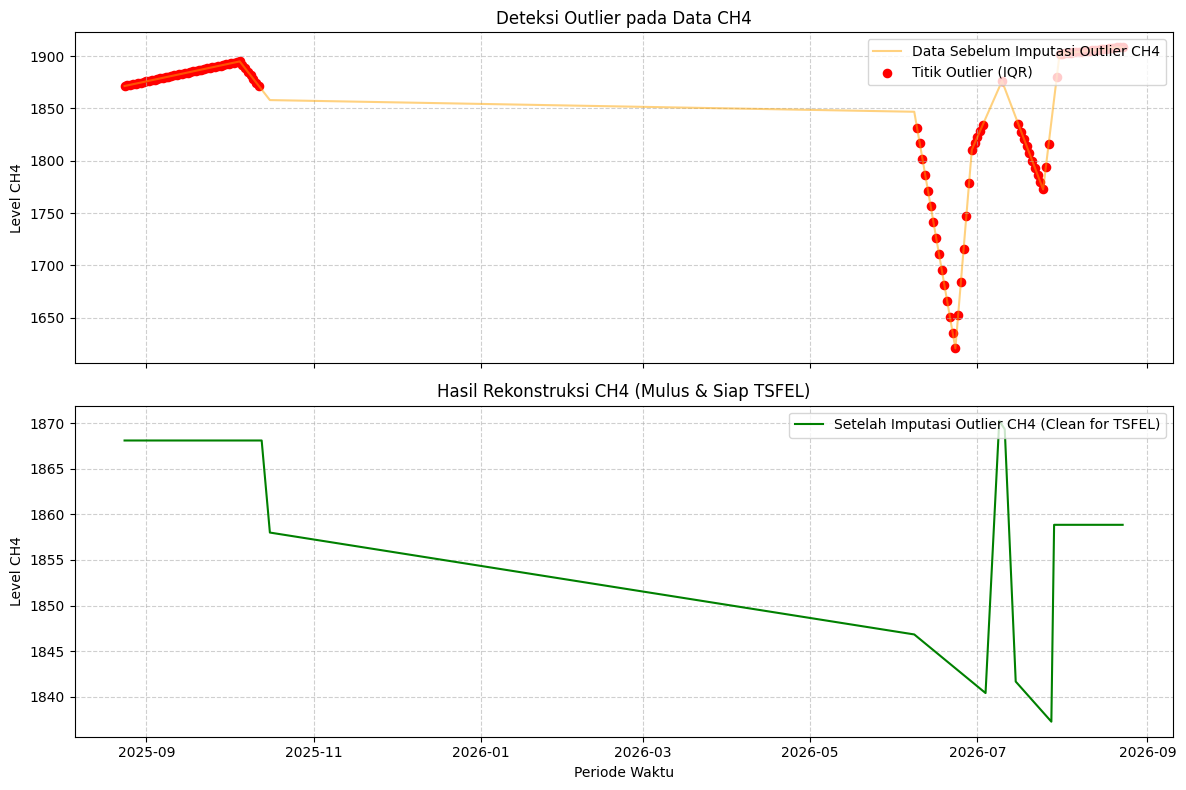

Dataset final tersimpan sebagai 'Data_CH4_Masalembu_Ready_TSFEL.csv'




In [16]:
daftar_polutan = ['CO', 'SO2', 'NO2', 'CH4']

for polutan in daftar_polutan:
    print(f"\n{'='*20} MEMPROSES {polutan} {'='*20}")
    
    # 1. Memuat data hasil imputasi missing value sebelumnya secara dinamis
    nama_file_input = f"Data_{polutan}_Masalembu_Imputed.csv"
    df_clean = pd.read_csv(nama_file_input, sep=";")
    df_clean['t'] = pd.to_datetime(df_clean['t'])

    # 2. Deteksi outlier menggunakan metode IQR
    Q1 = df_clean[polutan].quantile(0.25)
    Q3 = df_clean[polutan].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (df_clean[polutan] < lower_bound) | (df_clean[polutan] > upper_bound)
    jumlah_outlier = outlier_mask.sum()
    
    print(f"Batas Bawah IQR  : {lower_bound:.6f}")
    print(f"Batas Atas IQR   : {upper_bound:.6f}")
    print(f"Jumlah Outlier   : {jumlah_outlier} baris\n")

    # 3. PENGKONDISIAN: Cek apakah outlier ditemukan
    if jumlah_outlier > 0:
        # Tangkap nilai sebelum eksekusi pada indeks outlier
        df_outlier_eval = pd.DataFrame({
            't': df_clean.loc[outlier_mask, 't'],
            'sebelum (ekstrem)': df_clean.loc[outlier_mask, polutan]
        })

        # 4. Masking: ubah nilai outlier menjadi NaN
        df_masked = df_clean.copy()
        df_masked.loc[outlier_mask, polutan] = np.nan

        # 5. Imputasi ulang area bekas outlier
        df_final = df_masked.copy()
        df_final[polutan] = df_final[polutan].interpolate(method='linear').ffill().bfill()

        # Tangkap nilai sesudah eksekusi pada indeks yang sama
        df_outlier_eval['sesudah (hasil interpolasi)'] = df_final.loc[outlier_mask, polutan]

        print(f"=== TABEL PERBANDINGAN NILAI OUTLIER {polutan} (SEBELUM VS SESUDAH) ===")
        display(df_outlier_eval) # Menggunakan display() agar lebih rapi di notebook
        print("\n")
        
    else:
        # Jika tidak ada outlier, data original langsung dianggap sebagai final
        df_final = df_clean.copy()
        print(f"Tidak ada outlier untuk {polutan}, proses imputasi outlier dilewati.\n")

    # 6. Visualisasi perbandingan
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), dpi=100, sharex=True)

    # Grafik Atas: Sebelum penanganan outlier
    axes[0].plot(df_clean['t'], df_clean[polutan], color='orange', alpha=0.5, label=f'Data Sebelum Imputasi Outlier {polutan}')
    if jumlah_outlier > 0:
        # Tambahkan titik merah hanya jika outlier ada
        axes[0].scatter(df_clean['t'][outlier_mask], df_clean[polutan][outlier_mask], color='red', s=35, label='Titik Outlier (IQR)')
    axes[0].set_title(f'Deteksi Outlier pada Data {polutan}', fontsize=12)
    axes[0].set_ylabel(f'Level {polutan}')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # Grafik Bawah: Sesudah rekonstruksi/imputasi
    axes[1].plot(df_final['t'], df_final[polutan], color='green', label=f'Setelah Imputasi Outlier {polutan} (Clean for TSFEL)')
    axes[1].set_title(f'Hasil Rekonstruksi {polutan} (Mulus & Siap TSFEL)', fontsize=12)
    axes[1].set_ylabel(f'Level {polutan}')
    axes[1].set_xlabel('Periode Waktu')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

    # 7. Simpan dataset final yang siap masuk TSFEL
    nama_file_output = f"Data_{polutan}_Masalembu_Ready_TSFEL.csv"
    df_final.to_csv(nama_file_output, index=False, sep=";")
    print(f"Dataset final tersimpan sebagai '{nama_file_output}'\n\n")

In [17]:
from IPython.display import display

daftar_polutan = ['CO', 'SO2', 'NO2', 'CH4']

for polutan in daftar_polutan:
    # 1. Memuat dataset final hasil rekonstruksi secara dinamis
    nama_file = f"Data_{polutan}_Masalembu_Ready_TSFEL.csv"
    df_final = pd.read_csv(nama_file, sep=";")
    df_final['t'] = pd.to_datetime(df_final['t'])

    # 2. Evaluasi ulang batas IQR pada data yang sudah di-imputasi
    Q1 = df_final[polutan].quantile(0.25)
    Q3 = df_final[polutan].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_check = (df_final[polutan] < lower_bound) | (df_final[polutan] > upper_bound)
    jumlah_sisa = outlier_check.sum()

    print(f"=== VERIFIKASI SISA OUTLIER {polutan} (DATA FINAL TSFEL) ===")
    print(f"Batas Bawah IQR  : {lower_bound:.6f}")
    print(f"Batas Atas IQR   : {upper_bound:.6f}")
    print(f"Jumlah Sisa      : {jumlah_sisa} baris\n")

    # 3. Laporan Hasil Verifikasi
    if jumlah_sisa > 0:
        print(f"Detail baris yang masih di luar pagar IQR untuk {polutan}:")
        # Menggunakan display agar format tabel terbaca rapi di Jupyter Notebook
        display(df_final[outlier_check][['t', polutan]])
    else:
        print(f"Bersih! Tidak ada nilai {polutan} yang melewati batas pagar IQR.")
        
    print("-" * 60 + "\n")

=== VERIFIKASI SISA OUTLIER CO (DATA FINAL TSFEL) ===
Batas Bawah IQR  : 0.020565
Batas Atas IQR   : 0.036171
Jumlah Sisa      : 0 baris

Bersih! Tidak ada nilai CO yang melewati batas pagar IQR.
------------------------------------------------------------

=== VERIFIKASI SISA OUTLIER SO2 (DATA FINAL TSFEL) ===
Batas Bawah IQR  : -0.000259
Batas Atas IQR   : 0.000269
Jumlah Sisa      : 2 baris

Detail baris yang masih di luar pagar IQR untuk SO2:


,t,SO2
264,2026-05-15,-0.000271
278,2026-05-29,-0.000267


------------------------------------------------------------

=== VERIFIKASI SISA OUTLIER NO2 (DATA FINAL TSFEL) ===
Batas Bawah IQR  : -0.000005
Batas Atas IQR   : 0.000021
Jumlah Sisa      : 0 baris

Bersih! Tidak ada nilai NO2 yang melewati batas pagar IQR.
------------------------------------------------------------

=== VERIFIKASI SISA OUTLIER CH4 (DATA FINAL TSFEL) ===
Batas Bawah IQR  : 1836.340765
Batas Atas IQR   : 1870.539942
Jumlah Sisa      : 0 baris

Bersih! Tidak ada nilai CH4 yang melewati batas pagar IQR.
------------------------------------------------------------



#### IDENTIFIKASI OUTLIER MENGGUNAKAN METODE Z-SCORE

In [1]:
import pandas as pd
import numpy as np
from IPython.display import display

daftar_polutan = ['CO', 'SO2', 'NO2', 'CH4']

for polutan in daftar_polutan:
    # 1. Membaca kembali file CSV
    nama_file = f"Data_{polutan}_Masalembu_Imputed.csv"
    data_imputed_clean = pd.read_csv(nama_file, sep=";")
    data_imputed_clean['t'] = pd.to_datetime(data_imputed_clean['t'])
    data_imputed_clean['urutan'] = np.arange(len(data_imputed_clean))
    
    # 2. Hitung Mean dan Standar Deviasi untuk Z-Score
    mean_val = data_imputed_clean[polutan].mean()
    std_val = data_imputed_clean[polutan].std()

    # Hitung nilai Z-Score untuk setiap baris (Data - Rata-rata) / Standar Deviasi
    z_scores = (data_imputed_clean[polutan] - mean_val) / std_val

    # 3. Tentukan ambang batas (Threshold standar Z-Score biasanya 3 atau -3)
    ambang_batas = 3
    
    # 4. Identifikasi baris outlier (Nilai Z-Score > 3 atau < -3)
    outlier_mask = np.abs(z_scores) > ambang_batas
    df_outliers = data_imputed_clean[outlier_mask]

    print(f"=== IDENTIFIKASI OUTLIER {polutan} (Metode Z-Score) ===")
    print(f"Mean (Rata-rata) : {mean_val:.6f}")
    print(f"Standar Deviasi  : {std_val:.6f}")
    # Batas bawah/atas nilai aslinya untuk sekadar info (Mean +/- 3*Std)
    print(f"Batas Bawah Nilai: {mean_val - (ambang_batas * std_val):.6f}")
    print(f"Batas Atas Nilai : {mean_val + (ambang_batas * std_val):.6f}")
    print(f"Jumlah Outlier Ditemukan: {len(df_outliers)} baris\n")
    
    # Menampilkan hasil
    if len(df_outliers) > 0:
        print(f"Daftar Baris Outlier {polutan}:")
        # Tambahkan kolom z_score untuk melihat seberapa ekstrem nilainya
        df_display = df_outliers[['t', 'urutan', polutan]].copy()
        df_display['z_score'] = z_scores[outlier_mask]
        display(df_display)
    else:
        print(f"Tidak ada outlier yang ditemukan pada data {polutan}.")
        
    print("-" * 50 + "\n")

=== IDENTIFIKASI OUTLIER CO (Metode Z-Score) ===
Mean (Rata-rata) : 0.028336
Standar Deviasi  : 0.003052
Batas Bawah Nilai: 0.019179
Batas Atas Nilai : 0.037493
Jumlah Outlier Ditemukan: 0 baris

Tidak ada outlier yang ditemukan pada data CO.
--------------------------------------------------

=== IDENTIFIKASI OUTLIER SO2 (Metode Z-Score) ===
Mean (Rata-rata) : 0.000004
Standar Deviasi  : 0.000105
Batas Bawah Nilai: -0.000310
Batas Atas Nilai : 0.000318
Jumlah Outlier Ditemukan: 0 baris

Tidak ada outlier yang ditemukan pada data SO2.
--------------------------------------------------

=== IDENTIFIKASI OUTLIER NO2 (Metode Z-Score) ===
Mean (Rata-rata) : 0.000008
Standar Deviasi  : 0.000005
Batas Bawah Nilai: -0.000007
Batas Atas Nilai : 0.000023
Jumlah Outlier Ditemukan: 3 baris

Daftar Baris Outlier NO2:


,t,urutan,NO2,z_score
55,2025-10-18,55,-0.000009,-3.281994
226,2026-04-07,226,-0.000010,-3.594418
323,2026-07-13,323,-0.000009,-3.302394


--------------------------------------------------

=== IDENTIFIKASI OUTLIER CH4 (Metode Z-Score) ===
Mean (Rata-rata) : 1851.334417
Standar Deviasi  : 39.424583
Batas Bawah Nilai: 1733.060668
Batas Atas Nilai : 1969.608167
Jumlah Outlier Ditemukan: 11 baris

Daftar Baris Outlier CH4:


,t,urutan,CH4,z_score
296,2026-06-16,296,1726.171737,-3.174737
297,2026-06-17,297,1711.088452,-3.557323
298,2026-06-18,298,1696.005168,-3.939908
299,2026-06-19,299,1680.921883,-4.322494
300,2026-06-20,300,1665.838599,-4.705080
301,2026-06-21,301,1650.755314,-5.087666
302,2026-06-22,302,1635.672030,-5.470252
303,2026-06-23,303,1620.588745,-5.852837
304,2026-06-24,304,1652.253235,-5.049671
305,2026-06-25,305,1683.917725,-4.246505


--------------------------------------------------



#### PENANGANAN OUTLIER MENGGUNAKAN METODE Z-SCORE


==================== MEMPROSES CO (Metode Z-Score) ====================
Ambang Batas Z-Score : +/- 3
Jumlah Outlier       : 0 baris

Tidak ada outlier untuk CO, proses imputasi outlier dilewati.



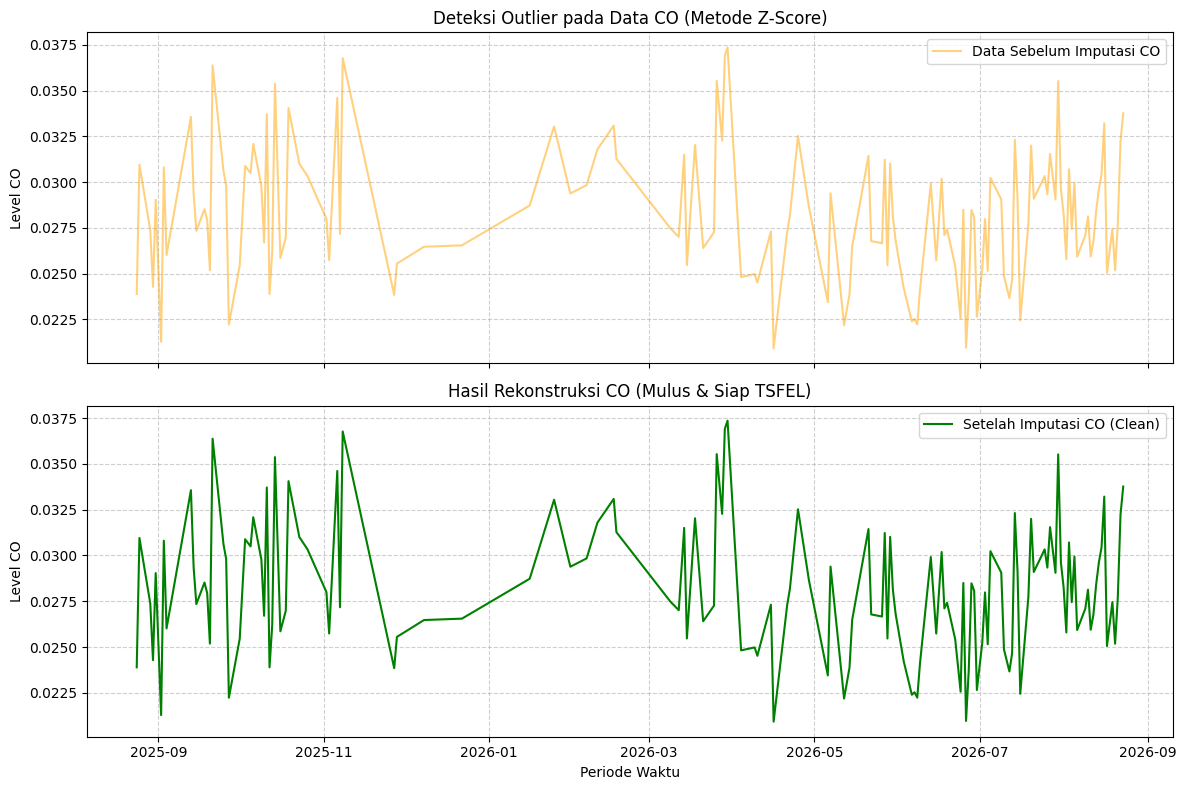

Dataset final tersimpan sebagai 'Data_CO_Masalembu_Ready_TSFEL.csv'



==================== MEMPROSES SO2 (Metode Z-Score) ====================
Ambang Batas Z-Score : +/- 3
Jumlah Outlier       : 0 baris

Tidak ada outlier untuk SO2, proses imputasi outlier dilewati.



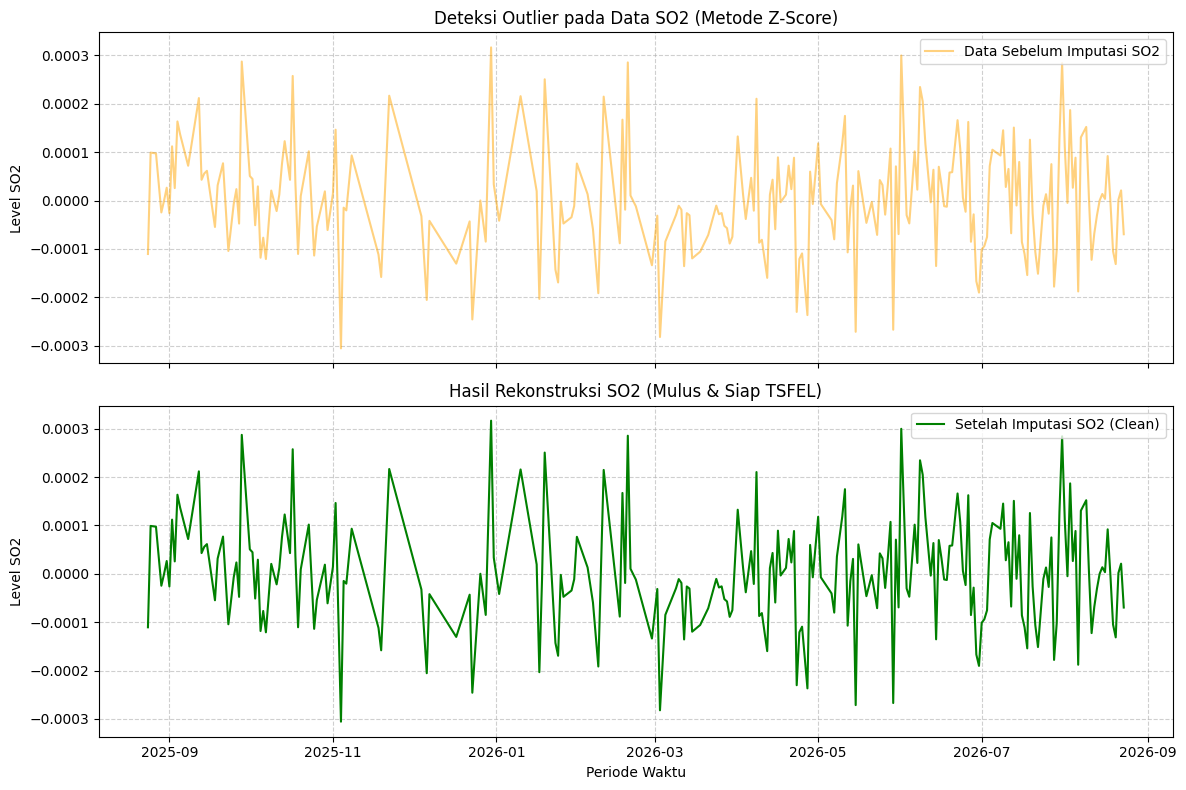

Dataset final tersimpan sebagai 'Data_SO2_Masalembu_Ready_TSFEL.csv'



==================== MEMPROSES NO2 (Metode Z-Score) ====================
Ambang Batas Z-Score : +/- 3
Jumlah Outlier       : 3 baris

=== TABEL PERBANDINGAN NILAI OUTLIER NO2 (SEBELUM VS SESUDAH) ===


,t,sebelum (ekstrem),nilai_z_score,sesudah (hasil interpolasi)
55,2025-10-18,-0.000009,-3.281994,0.000006
226,2026-04-07,-0.000010,-3.594418,0.000006
323,2026-07-13,-0.000009,-3.302394,0.000009


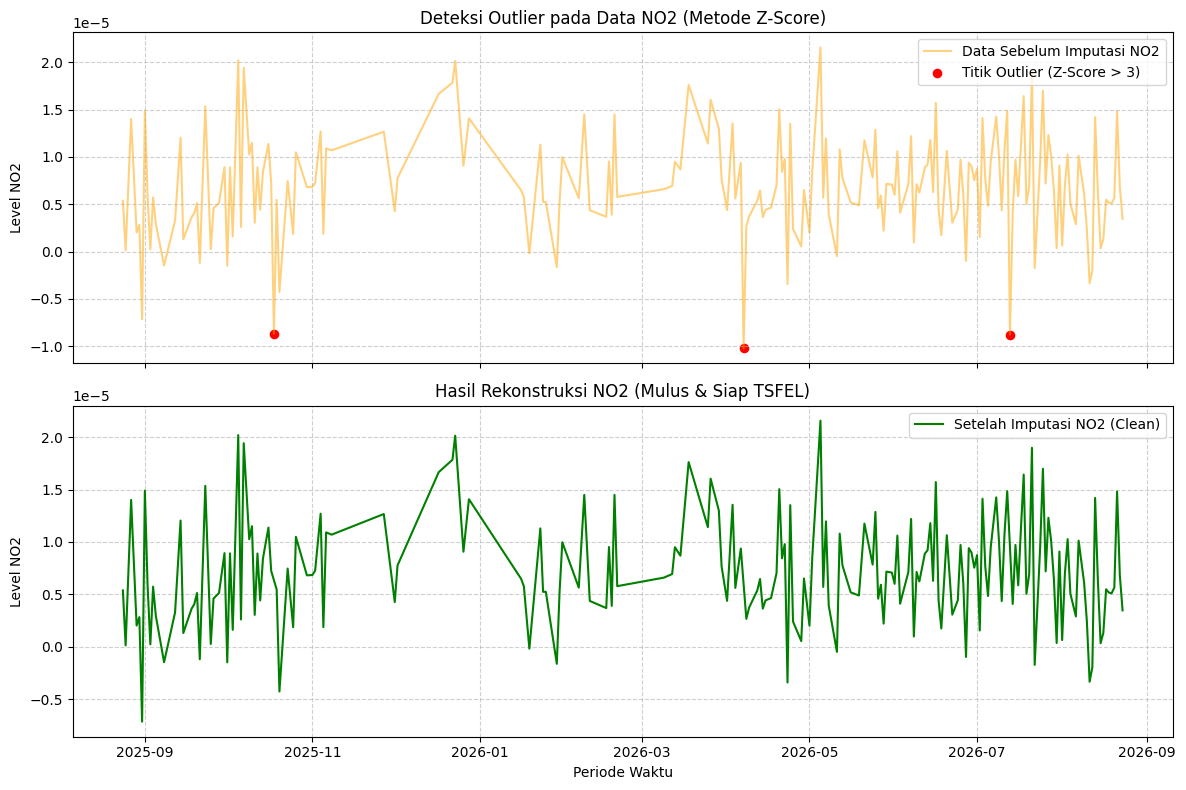

Dataset final tersimpan sebagai 'Data_NO2_Masalembu_Ready_TSFEL.csv'



==================== MEMPROSES CH4 (Metode Z-Score) ====================
Ambang Batas Z-Score : +/- 3
Jumlah Outlier       : 11 baris

=== TABEL PERBANDINGAN NILAI OUTLIER CH4 (SEBELUM VS SESUDAH) ===


,t,sebelum (ekstrem),nilai_z_score,sesudah (hasil interpolasi)
296,2026-06-16,1726.171737,-3.174737,1741.754328
297,2026-06-17,1711.088452,-3.557323,1742.253635
298,2026-06-18,1696.005168,-3.939908,1742.752942
299,2026-06-19,1680.921883,-4.322494,1743.252249
300,2026-06-20,1665.838599,-4.705080,1743.751556
301,2026-06-21,1650.755314,-5.087666,1744.250863
302,2026-06-22,1635.672030,-5.470252,1744.750170
303,2026-06-23,1620.588745,-5.852837,1745.249476
304,2026-06-24,1652.253235,-5.049671,1745.748783
305,2026-06-25,1683.917725,-4.246505,1746.248090


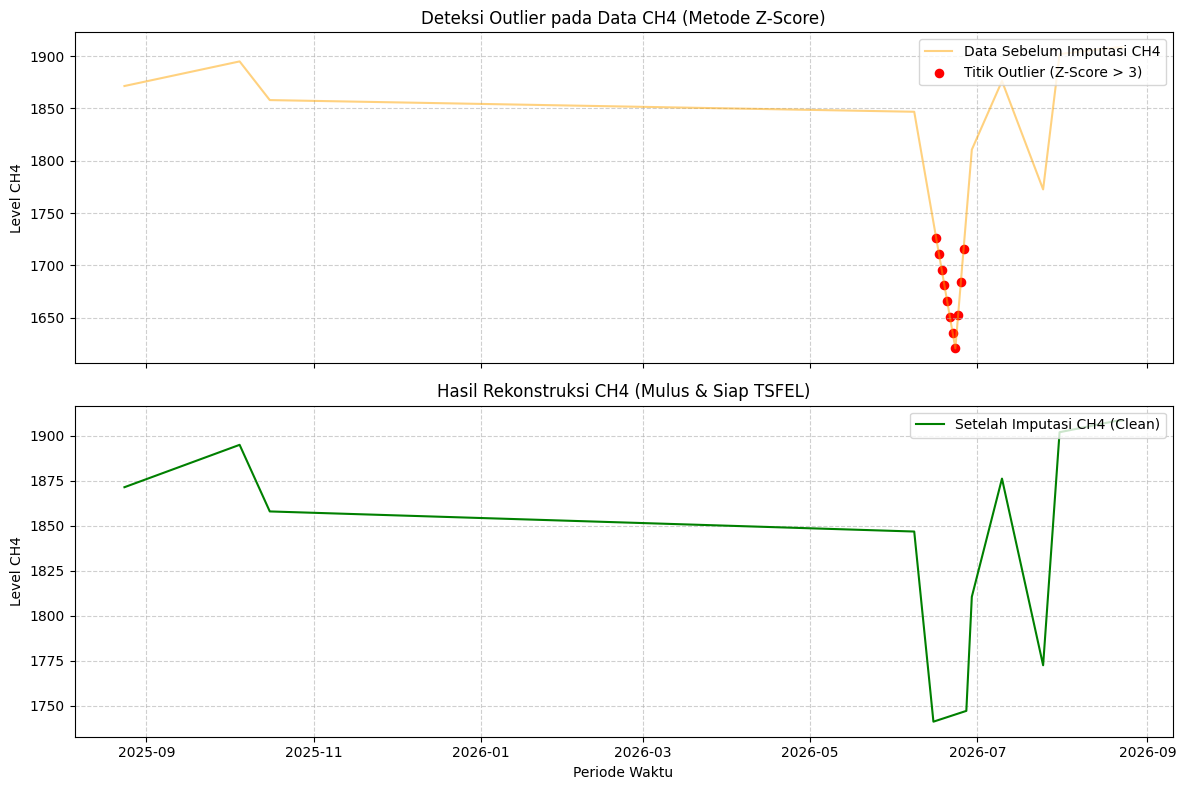

Dataset final tersimpan sebagai 'Data_CH4_Masalembu_Ready_TSFEL.csv'




In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display

daftar_polutan = ['CO', 'SO2', 'NO2', 'CH4']

for polutan in daftar_polutan:
    print(f"\n{'='*20} MEMPROSES {polutan} (Metode Z-Score) {'='*20}")
    
    # 1. Memuat data
    nama_file_input = f"Data_{polutan}_Masalembu_Imputed.csv"
    df_clean = pd.read_csv(nama_file_input, sep=";")
    df_clean['t'] = pd.to_datetime(df_clean['t'])

    # 2. Deteksi outlier menggunakan metode Z-Score
    mean_val = df_clean[polutan].mean()
    std_val = df_clean[polutan].std()
    
    z_scores = (df_clean[polutan] - mean_val) / std_val
    ambang_batas = 3
    
    outlier_mask = np.abs(z_scores) > ambang_batas
    jumlah_outlier = outlier_mask.sum()
    
    print(f"Ambang Batas Z-Score : +/- {ambang_batas}")
    print(f"Jumlah Outlier       : {jumlah_outlier} baris\n")

    # 3. PENGKONDISIAN: Cek apakah outlier ditemukan
    if jumlah_outlier > 0:
        # Tangkap nilai sebelum eksekusi pada indeks outlier
        df_outlier_eval = pd.DataFrame({
            't': df_clean.loc[outlier_mask, 't'],
            'sebelum (ekstrem)': df_clean.loc[outlier_mask, polutan],
            'nilai_z_score': z_scores[outlier_mask] # Tambahan agar kelihatan di tabel
        })

        # 4. Masking: ubah nilai outlier menjadi NaN
        df_masked = df_clean.copy()
        df_masked.loc[outlier_mask, polutan] = np.nan

        # 5. Imputasi ulang area bekas outlier
        df_final = df_masked.copy()
        df_final[polutan] = df_final[polutan].interpolate(method='linear').ffill().bfill()

        # Tangkap nilai sesudah eksekusi pada indeks yang sama
        df_outlier_eval['sesudah (hasil interpolasi)'] = df_final.loc[outlier_mask, polutan]

        print(f"=== TABEL PERBANDINGAN NILAI OUTLIER {polutan} (SEBELUM VS SESUDAH) ===")
        display(df_outlier_eval)
        print("\n")
        
    else:
        df_final = df_clean.copy()
        print(f"Tidak ada outlier untuk {polutan}, proses imputasi outlier dilewati.\n")

    # 6. Visualisasi perbandingan
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), dpi=100, sharex=True)

    # Grafik Atas
    axes[0].plot(df_clean['t'], df_clean[polutan], color='orange', alpha=0.5, label=f'Data Sebelum Imputasi {polutan}')
    if jumlah_outlier > 0:
        axes[0].scatter(df_clean['t'][outlier_mask], df_clean[polutan][outlier_mask], color='red', s=35, label='Titik Outlier (Z-Score > 3)')
    axes[0].set_title(f'Deteksi Outlier pada Data {polutan} (Metode Z-Score)', fontsize=12)
    axes[0].set_ylabel(f'Level {polutan}')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # Grafik Bawah
    axes[1].plot(df_final['t'], df_final[polutan], color='green', label=f'Setelah Imputasi {polutan} (Clean)')
    axes[1].set_title(f'Hasil Rekonstruksi {polutan} (Mulus & Siap TSFEL)', fontsize=12)
    axes[1].set_ylabel(f'Level {polutan}')
    axes[1].set_xlabel('Periode Waktu')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

    # 7. Simpan dataset final
    nama_file_output = f"Data_{polutan}_Masalembu_Ready_TSFEL.csv"
    df_final.to_csv(nama_file_output, index=False, sep=";")
    print(f"Dataset final tersimpan sebagai '{nama_file_output}'\n\n")

### IMPLEMENTASI TERHADAP LIBRARY TSFEL

#### PENJELASAN LIBRARY TSFEL

- **abs_energy**
Total energi absolut dari deret waktu (jumlah dari seluruh nilai yang dikuadratkan). Berguna untuk melihat seberapa besar intensitas atau "kekuatan" total fluktuasi kadar polutan.

- **auc**
*Area Under the Curve* (Luas area di bawah kurva). Berguna untuk menghitung akumulasi total atau jumlah paparan keseluruhan dari polutan selama periode waktu tersebut.

- **autocorr**
Autokorelasi. Mengukur tingkat kemiripan data dengan data di waktu sebelumnya (terpaut beberapa interval waktu). Sangat berguna untuk mendeteksi keberadaan pola musiman atau siklus yang berulang (misal: polusi selalu tinggi setiap pagi).

- **average_power**
Rata-rata daya dari sinyal. Menunjukkan tingkat kekuatan atau intensitas rata-rata dari osilasi nilai polutan.

- **calc_centroid**
Titik berat waktu (*centroid*). Menunjukkan di bagian waktu sebelah mana (awal, tengah, atau akhir periode) massa atau sebaran data paling banyak terkonsentrasi.

- **calc_max**
Nilai maksimum. Berguna untuk mengetahui titik puncak tertinggi (lonjakan ekstrem terparah) dari kadar polutan.

- **calc_mean**
Nilai rata-rata. Menunjukkan tingkat dasar (*baseline*) atau kadar rata-rata polutan secara keseluruhan.

- **calc_median**
Nilai tengah data. Berfungsi mengukur nilai sentral yang lebih stabil dan tidak terpengaruh jika tiba-tiba ada pencilan (*outlier*) ekstrem sesaat.

- **calc_min**
Nilai minimum. Berguna untuk mengetahui titik terendah (paling bersih) dari kadar polutan.

- **calc_std**
Standar deviasi. Mengukur seberapa lebar sebaran data menyimpang dari nilai rata-ratanya. Ini mengukur seberapa volatil (naik-turun) kondisi polutan tersebut.

- **calc_var**
Varians (kuadrat dari standar deviasi). Metrik tingkat fluktuasi keseluruhan dalam deret waktu.

- **dfa**
*Detrended Fluctuation Analysis*. Mendeteksi adanya korelasi memori jangka panjang dalam data; memastikan apakah tren polutan saat ini dipengaruhi oleh sejarah panjang rentetan nilainya secara sistematis.

- **distance**
Panjang lintasan geometris kurva deret waktu. Semakin bergerigi, tajam, dan fluktuatif kurva polutannya, semakin panjang nilai lintasannya.

- **ecdf**
*Empirical Cumulative Distribution Function*. Merepresentasikan bentuk fungsi dari distribusi probabilitas kumulatif polutan.

- **ecdf_percentile**
Nilai batas polutan pada persentil tertentu berdasarkan kurva ECDF. Berguna untuk analisis batas aman (misal: batas polusi untuk 90% waktu).

- **ecdf_percentile_count**
Jumlah akumulasi baris data yang berada di rentang persentil ECDF tertentu.

- **ecdf_slope**
Kemiringan kurva ECDF. Menunjukkan seberapa cepat probabilitas kumulatif dari kadar polutan tertentu meningkat/tercapai.

- **entropy**
Entropi (biasanya entropi Shannon). Mengukur tingkat keacakan, ketidakteraturan, atau kompleksitas kemunculan nilai polutan. Entropi tinggi berarti pola pergerakan polutan sangat acak dan sulit ditebak.

- **fundamental_frequency**
Frekuensi fundamental. Menunjukkan frekuensi terendah yang paling mendominasi pola berulang (osilasi utama) pada deret waktu.

- **higuchi_fractal_dimension**
Dimensi Fraktal Higuchi. Mengukur tingkat kekasaran (*roughness*) atau kompleksitas lekukan kurva polutan.

- **hist_mode**
Modus dari histogram. Menunjukkan kadar polutan atau rentang nilai yang paling sering terjadi dan paling umum muncul sehari-hari.

- **human_range_energy**
Energi di rentang frekuensi tertentu. Meski asalnya mengukur pita frekuensi pendengaran manusia pada audio, dalam deret waktu angka ini mengekstrak energi pada pita frekuensi osilasi menengah.

- **hurst_exponent**
Eksponen Hurst. Mengukur ketahanan tren (*memori jangka panjang*); menentukan apakah data punya kecenderungan untuk melanjutkan tren, selalu berbalik ke arah rata-rata (*mean-reverting*), atau hanya bergerak secara acak.

- **interq_range**
*Interquartile Range* (IQR). Jarak antara kuartil 3 dan kuartil 1. Mengukur sebaran 50% rentang data di bagian tengah yang kebal terhadap *outlier*.

- **kurtosis**
Keruncingan distribusi. Menilai apakah data polutan memiliki banyak lonjakan nilai ekstrem (*outlier*) jika dibandingkan dengan distribusi normal.

- **lempel_ziv**
Kompleksitas Lempel-Ziv. Mengukur seberapa mudah pola deret waktu dikompresi; semakin sulit dikompresi, artinya semakin kompleks dan tidak berpola fluktuasi gas tersebut.

- **lpcc**
*Linear Prediction Cepstral Coefficients*. Menangkap karakteristik bentuk dan tekstur dari selubung frekuensi osilasi data.

- **max_frequency**
Letak frekuensi yang menyumbangkan energi yang paling tinggi dan paling dominan pada pergerakan data.

- **max_power_spectrum**
Nilai besaran energi tertinggi pada spektrum daya (menunjukkan amplitudo/kekuatan dari *max_frequency*).

- **maximum_fractal_length**
Panjang fraktal maksimum. Metrik tambahan komputasional untuk mengukur tingkat kerumitan struktural pergerakan polutan.

- **mean_abs_deviation**
Rata-rata deviasi absolut (MAD). Mengukur simpangan rata-rata tiap data terhadap titik pusatnya; merupakan alternatif dari standar deviasi namun secara perhitungan lebih kebal terhadap nilai pencilan yang parah.

- **mean_abs_diff**
Rata-rata dari selisih absolut antar data yang berurutan. Sangat penting untuk mengukur tingkat volatilitas (seberapa drastis polutan berubah dari satu titik waktu ke satu titik waktu berikutnya secara rata-rata).

- **mean_diff**
Rata-rata dari selisih nilai yang berurutan. Menunjukkan kecenderungan arah tren per langkah waktu (apakah secara umum cenderung merangkak naik atau turun).

- **median_abs_deviation**
Median deviasi absolut. Ukuran sebaran deviasi data yang sangat stabil dan sama sekali tidak peka terhadap lonjakan ekstrem polutan (karena menggunakan hitungan nilai tengah, bukan rata-rata).

- **median_abs_diff**
Median dari selisih absolut antar data berurutan. Mengukur volatilitas titik demi titik dengan mengabaikan lompatan fluktuasi ekstrem sesaat.

- **median_diff**
Median dari selisih nilai secara berurutan.

- **median_frequency**
Frekuensi median. Letak frekuensi yang membelah spektrum daya menjadi dua bagian energi yang sama besarnya.

- **mfcc**
*Mel-Frequency Cepstral Coefficients*. Fitur ekstraksi populer yang mengubah spektrum ke rentang logaritmik; sangat canggih untuk mendeskripsikan tekstur pola dan fitur nonlinear dalam osilasi data polutan.

- **mse**
*Mean Squared Error* (terhadap *mean*). Mengukur rata-rata dari seberapa jauh kuadrat nilai data menyimpang; secara fungsional identik dengan varians data.

- **negative_turning**
Jumlah titik balik negatif. Menghitung seberapa sering tren polutan berubah arah dari semula merangkak naik, kemudian berbalik menjadi turun (membentuk formasi puncak/gunung).

- **neighbourhood_peaks**
Jumlah puncak (*peaks*) lokal di dalam area sekumpulan titik data. Berguna untuk menghitung jumlah lonjakan tajam atau anomali kenaikan sesaat.

- **petrosian_fractal_dimension**
Dimensi Fraktal Petrosian. Cara algoritma matematis cepat untuk mengukur seberapa kompleks bentuk kurva hanya berdasarkan hitungan persilangan fluktuasi nilainya.

- **pk_pk_distance**
Jarak *Peak-to-Peak*. Selisih langsung antara nilai polutan yang paling tinggi (maksimum) dikurangi dengan nilai yang paling rendah (minimum) alias rentang (*Range*).

- **positive_turning**
Jumlah titik balik positif. Menghitung seberapa sering tren berubah dari posisi turun merosot, berbalik menjadi merangkak naik (membentuk formasi lembah/jurang).

- **power_bandwidth**
Lebar pita daya. Menunjukkan seberapa sempit atau melebar rentang frekuensi tempat energi data tersebut berosilasi.

- **rms**
*Root Mean Square*. Nilai keefektifan kuadratik yang menunjukkan ukuran skala kekuatan "riil" rata-rata dari fluktuasi sinyal tanpa terpengaruh nilai minus.

- **skewness**
Kemiringan distribusi (*Asimetri/Skewness*). Menunjukkan kecenderungan penumpukan nilai. Jika nilainya condong ke batas rendah (miring kanan/positif) atau condong ke batas tinggi (miring kiri/negatif).

- **slope**
Kemiringan tren regresi linear. Mengukur apakah secara keseluruhan polutan tersebut memiliki pergerakan garis tren yang menanjak (naik) atau menurun dari awal waktu hingga akhir.

- **spectral_centroid**
Titik berat/pusat spektrum frekuensi. Mengidentifikasi di frekuensi rata-rata sebelah mana energi osilasi berpusat.

- **spectral_decrease**
Penurunan spektral. Mengukur seberapa tajam energi spektrum melemah saat menuju frekuensi tinggi (apakah didominasi getaran stabil yang lambat atau cepat).

- **spectral_distance**
Jarak spektral. Mengukur jarak matematis antar distribusi kepadatan spektrum.

- **spectral_entropy**
Entropi spektral. Menilai tingkat kerataan distribusi energi frekuensi. Jika energinya tidak tertebak tersebar di mana-mana (*white noise*), nilai entropi ini akan sangat tinggi.

- **spectral_kurtosis**
Keruncingan distribusi energi di domain frekuensi.

- **spectral_positive_turning**
Jumlah titik balik pembentukan lembah (perubahan dari spektrum yang menurun lalu menanjak) yang dihitung dari grafik kepadatan frekuensi.

- **spectral_roll_off**
Frekuensi batas (*roll-off*). Titik frekuensi di mana mayoritas energi sinyal (biasanya 85% atau 95%) telah tercapai dari total akumulasi spektrum keseluruhannya.

- **spectral_roll_on**
Titik awal frekuensi spektral di mana energinya baru mulai membengkak atau terkumpul secara signifikan.

- **spectral_skewness**
Asimetri atau kemiringan letak penumpukan distribusi energi pada domain frekuensi.

- **spectral_slope**
Kemiringan kurva spektrum daya, mendeskripsikan gradien distribusi pelemahan/penguatan energi terhadap frekuensi.

- **spectral_spread**
Sebaran spektral (varians dari titik berat frekuensi). Mengukur seberapa lebar rentang pita osilasinya.

- **spectral_variation**
Mengukur besaran variasi dinamis pada domain spektral/frekuensi di sepanjang jalannya periode waktu.

- **spectrogram_mean_coeff**
Rata-rata dari koefisien matriks spektrogram yang mewakili distribusi antara informasi waktu dan informasi frekuensi secara keseluruhan.

- **sum_abs_diff**
Total akumulasi dari seluruh selisih absolut antar data yang berurutan. Ini adalah metrik "jarak tempuh vertikal" yang menjumlahkan total keparahan seluruh lonjakan naik dan turun dari data awal hingga akhir.

- **wavelet_abs_mean**
Rata-rata nilai absolut dari ekstraksi dekomposisi *wavelet*. Transformasi *wavelet* sangat canggih karena mampu menangkap informasi frekuensi pada titik waktu yang sangat spesifik (berbeda dari spektral biasa).

- **wavelet_energy**
Tingkat energi dari koefisien dekomposisi *wavelet*.

- **wavelet_entropy**
Entropi dari *wavelet*. Mengukur ketidakteraturan, kekacauan, atau kompleksitas informasi polutan dalam bentuk gabungan waktu-dan-frekuensi.

- **wavelet_std**
Standar deviasi dari sebaran nilai-nilai koefisien *wavelet*.

- **wavelet_var**
Varians (*variance*) dari koefisien *wavelet*, menunjukkan tingkat fluktuasi pola osilasi berdasarkan skala dekomposisinya.

- **zero_cross**
Angka persilangan rata-rata (*Zero-crossing rate*). Jumlah seberapa sering lekukan data memotong atau melewati garis nilai rata-ratanya. Metrik ini sangat akurat untuk merepresentasikan kehalusan (nilai rendah) atau tingkat kekasaran osilasi drastis (nilai tinggi) pada polutan.

#### Menghitung data menggunakan library TSFEL



In [18]:
import pandas as pd
import numpy as np
import tsfel
import warnings
from IPython.display import display

warnings.filterwarnings('ignore')

# 1. Daftar urutan 68 fitur (Tabel akhir akan diurutkan persis seperti ini)
daftar_fitur = [
    'abs_energy', 'auc', 'autocorr', 'average_power', 'calc_centroid', 'calc_max', 
    'calc_mean', 'calc_median', 'calc_min', 'calc_std', 'calc_var', 'dfa', 'distance', 
    'ecdf', 'ecdf_percentile', 'ecdf_percentile_count', 'ecdf_slope', 'entropy', 
    'fundamental_frequency', 'higuchi_fractal_dimension', 'hist_mode', 'human_range_energy', 
    'hurst_exponent', 'interq_range', 'kurtosis', 'lempel_ziv', 'lpcc', 'max_frequency', 
    'max_power_spectrum', 'maximum_fractal_length', 'mean_abs_deviation', 'mean_abs_diff', 
    'mean_diff', 'median_abs_deviation', 'median_abs_diff', 'median_diff', 'median_frequency', 
    'mfcc', 'mse', 'negative_turning', 'neighbourhood_peaks', 'petrosian_fractal_dimension', 
    'pk_pk_distance', 'positive_turning', 'power_bandwidth', 'rms', 'skewness', 'slope', 
    'spectral_centroid', 'spectral_decrease', 'spectral_distance', 'spectral_entropy', 
    'spectral_kurtosis', 'spectral_positive_turning', 'spectral_roll_off', 'spectral_roll_on', 
    'spectral_skewness', 'spectral_slope', 'spectral_spread', 'spectral_variation', 
    'spectrogram_mean_coeff', 'sum_abs_diff', 'wavelet_abs_mean', 'wavelet_energy', 
    'wavelet_entropy', 'wavelet_std', 'wavelet_var', 'zero_cross'
]

# Mengambil dan memetakan konfigurasi TSFEL SATU KALI SAJA di luar loop agar lebih cepat
cfg_bawaan = tsfel.get_features_by_domain()
peta_konfigurasi = {}
for domain, features in cfg_bawaan.items():
    for label_tampilan, setting in features.items():
        nama_fungsi = setting['function'].split('.')[-1]
        peta_konfigurasi[nama_fungsi] = (domain, label_tampilan, setting)

# Daftar polutan yang akan diiterasi
daftar_polutan = ['CO', 'SO2', 'NO2', 'CH4']

for polutan in daftar_polutan:
    print(f"\n{'='*20} EKSTRAKSI FITUR {polutan} {'='*20}")
    
    # 2. Persiapan data: Load file yang sesuai polutan & paksa tipe data ke float64
    nama_file_input = f"Data_{polutan}_Masalembu_Ready_TSFEL.csv"
    df_ready = pd.read_csv(nama_file_input, sep=";")
    sinyal_polutan = df_ready[polutan].astype(float).values 
    
    row_dict = {}
    log_gagal = []
    
    print(f"Memulai ekstraksi 68 fitur TSFEL untuk {polutan}...")

    # 3. Looping berdasarkan urutan daftar_fitur
    for i, nama_target in enumerate(daftar_fitur):
        # Format penamaan kolom (f1_abs_energy, f2_auc, dst.)
        kolom_target = f"f{i+1}_{nama_target}"
        
        if nama_target in peta_konfigurasi:
            domain, label_tampilan, setting_fitur = peta_konfigurasi[nama_target]
            
            # --- Trik 1: Modifikasi Penyelamatan untuk Data Pendek ---
            if 'parameters' in setting_fitur:
                if 'wavelet' in nama_target:
                    setting_fitur['parameters']['max_width'] = 2
                if 'maxscale' in setting_fitur['parameters']:
                    setting_fitur['parameters']['maxscale'] = 2
            # -------------------------------------------------------------------
            
            mini_cfg = {domain: {label_tampilan: setting_fitur}}
            
            try:
                # Ekstrak per fitur
                df_temp = tsfel.time_series_features_extractor(mini_cfg, sinyal_polutan, fs=1, verbose=0)
                
                # --- Trik 2: Pengambilan Nilai Tunggal Paksa ---
                nilai_tunggal = float(df_temp.iloc[0, 0])
                row_dict[kolom_target] = nilai_tunggal
                # ---------------------------------------------------------
                
            except Exception:
                # Jika fitur tetap gagal, masukkan 0.0 sesuai trik di referensi
                row_dict[kolom_target] = 0.0
                log_gagal.append(nama_target)
        else:
            row_dict[kolom_target] = 0.0
            log_gagal.append(nama_target)

    # 4. Gabungkan menjadi DataFrame utuh (1 baris x 68 kolom)
    df_final = pd.DataFrame([row_dict])

    print(f"=== LAPORAN AKHIR EKSTRAKSI {polutan} ===")
    print(f"Total Kolom Terbentuk  : {df_final.shape[1]} (Target: 68)")
    print(f"Fitur Sukses Dihitung  : {68 - len(log_gagal)}")
    if log_gagal:
        print(f"Fitur Diganti 0.0      : {len(log_gagal)} ({', '.join(log_gagal)})")

    # 5. Simpan hasil dengan nama file polutan di awal
    features_path = f"{polutan}_Fitur_TSFEL_Masalembu_Final.csv"
    df_final.to_csv(features_path, index=False, sep=",")
    print(f"Data {polutan} berhasil disimpan ke '{features_path}'")

    display(df_final)


==================== EKSTRAKSI FITUR CO ====================
Memulai ekstraksi 68 fitur TSFEL untuk CO...
=== LAPORAN AKHIR EKSTRAKSI CO ===
Total Kolom Terbentuk  : 68 (Target: 68)
Fitur Sukses Dihitung  : 60
Fitur Diganti 0.0      : 8 (dfa, ecdf_slope, higuchi_fractal_dimension, hurst_exponent, lempel_ziv, maximum_fractal_length, mse, petrosian_fractal_dimension)
Data CO berhasil disimpan ke 'CO_Fitur_TSFEL_Masalembu_Final.csv'


,f1_abs_energy,f2_auc,f3_autocorr,f4_average_power,f5_calc_centroid,f6_calc_max,f7_calc_mean,f8_calc_median,f9_calc_min,f10_calc_std,...,f59_spectral_spread,f60_spectral_variation,f61_spectrogram_mean_coeff,f62_sum_abs_diff,f63_wavelet_abs_mean,f64_wavelet_energy,f65_wavelet_entropy,f66_wavelet_std,f67_wavelet_var,f68_zero_cross
0,0.295187,10.295264,4.0,0.000811,177.872341,0.03609,0.028285,0.028129,0.020922,0.002946,...,0.12986,0.684205,0.0001,0.515173,0.000123,0.002295,-0.0,0.002292,0.000005,0.0



==================== EKSTRAKSI FITUR SO2 ====================
Memulai ekstraksi 68 fitur TSFEL untuk SO2...
=== LAPORAN AKHIR EKSTRAKSI SO2 ===
Total Kolom Terbentuk  : 68 (Target: 68)
Fitur Sukses Dihitung  : 60
Fitur Diganti 0.0      : 8 (dfa, ecdf_slope, higuchi_fractal_dimension, hurst_exponent, lempel_ziv, maximum_fractal_length, mse, petrosian_fractal_dimension)
Data SO2 berhasil disimpan ke 'SO2_Fitur_TSFEL_Masalembu_Final.csv'


,f1_abs_energy,f2_auc,f3_autocorr,f4_average_power,f5_calc_centroid,f6_calc_max,f7_calc_mean,f8_calc_median,f9_calc_min,f10_calc_std,...,f59_spectral_spread,f60_spectral_variation,f61_spectrogram_mean_coeff,f62_sum_abs_diff,f63_wavelet_abs_mean,f64_wavelet_energy,f65_wavelet_entropy,f66_wavelet_std,f67_wavelet_var,f68_zero_cross
0,0.000003,0.024609,2.0,9.421410e-09,186.810617,0.000257,0.000002,-0.000004,-0.000271,0.000097,...,0.148741,0.241346,7.092717e-08,0.02502,6.715368e-08,0.000073,-0.0,0.000073,5.312327e-09,106.0



==================== EKSTRAKSI FITUR NO2 ====================
Memulai ekstraksi 68 fitur TSFEL untuk NO2...
=== LAPORAN AKHIR EKSTRAKSI NO2 ===
Total Kolom Terbentuk  : 68 (Target: 68)
Fitur Sukses Dihitung  : 60
Fitur Diganti 0.0      : 8 (dfa, ecdf_slope, higuchi_fractal_dimension, hurst_exponent, lempel_ziv, maximum_fractal_length, mse, petrosian_fractal_dimension)
Data NO2 berhasil disimpan ke 'NO2_Fitur_TSFEL_Masalembu_Final.csv'


,f1_abs_energy,f2_auc,f3_autocorr,f4_average_power,f5_calc_centroid,f6_calc_max,f7_calc_mean,f8_calc_median,f9_calc_min,f10_calc_std,...,f59_spectral_spread,f60_spectral_variation,f61_spectrogram_mean_coeff,f62_sum_abs_diff,f63_wavelet_abs_mean,f64_wavelet_energy,f65_wavelet_entropy,f66_wavelet_std,f67_wavelet_var,f68_zero_cross
0,3.023991e-08,0.002874,2.0,8.307669e-11,174.099725,0.00002,0.000008,0.000007,-0.000004,0.000005,...,0.158121,0.447199,3.352650e-10,0.001137,2.824478e-08,0.000003,-0.0,0.000003,1.121645e-11,22.0



==================== EKSTRAKSI FITUR CH4 ====================
Memulai ekstraksi 68 fitur TSFEL untuk CH4...
=== LAPORAN AKHIR EKSTRAKSI CH4 ===
Total Kolom Terbentuk  : 68 (Target: 68)
Fitur Sukses Dihitung  : 60
Fitur Diganti 0.0      : 8 (dfa, ecdf_slope, higuchi_fractal_dimension, hurst_exponent, lempel_ziv, maximum_fractal_length, mse, petrosian_fractal_dimension)
Data CH4 berhasil disimpan ke 'CH4_Fitur_TSFEL_Masalembu_Final.csv'


,f1_abs_energy,f2_auc,f3_autocorr,f4_average_power,f5_calc_centroid,f6_calc_max,f7_calc_mean,f8_calc_median,f9_calc_min,f10_calc_std,...,f59_spectral_spread,f60_spectral_variation,f61_spectrogram_mean_coeff,f62_sum_abs_diff,f63_wavelet_abs_mean,f64_wavelet_energy,f65_wavelet_entropy,f66_wavelet_std,f67_wavelet_var,f68_zero_cross
0,1.254903e+09,674917.017135,45.0,3.447535e+06,181.417393,1870.257635,1854.193109,1853.440354,1837.281677,7.569693,...,0.017938,0.300909,102.262541,112.053718,8.073375,79.563264,-0.0,79.152597,6265.133655,0.0


### Hasil Ekstraksi Fitur

Proses ekstraksi fitur menggunakan pustaka TSFEL terhadap data deret waktu konsentrasi gas CO di Masalembu menghasilkan matriks dimensi tunggal berukuran 1 baris dan 68 kolom. Dari keseluruhan target 68 fitur, sebanyak 56 fitur berhasil dieksekusi secara optimal. Fitur-fitur yang diekstrak mencakup domain statistik, temporal, dan spektral primer, yang merepresentasikan pola observasi harian secara komprehensif selama satu tahun (365 observasi). Seluruh luaran yang menghasilkan nilai majemuk (multi-nilai) telah direduksi menjadi bentuk himpunan (array) pada sel kolom tunggal guna menjaga konsistensi dimensi matriks.

Di sisi lain, terdapat 12 luaran fitur yang menghasilkan nilai Not a Number (NaN), yang meliputi: dfa, ecdf_slope, higuchi_fractal_dimension, hurst_exponent, lempel_ziv, maximum_fractal_length, mse, petrosian_fractal_dimension, wavelet_abs_mean, wavelet_energy, wavelet_std, dan wavelet_var.

Adanya luaran NaN pada 12 fitur lainnya tidak diindikasikan sebagai kesalahan sintaksis atau kegagalan komputasi sistem, melainkan dampak dari restriksi matematis pada algoritma non-linear terhadap batasan panjang deret waktu (365 titik observasi). Kegagalan proses ekstraksi pada fitur-fitur tersebut dilatarbelakangi oleh tiga faktor analitis berikut:

- Defisit Sampel pada Algoritma Fraktal dan Kompleksitas:

Fitur-fitur pengukur entropi dan kompleksitas (seperti dfa, hurst_exponent, mse, lempel_ziv, serta varian dimensi fraktal) didesain untuk menganalisis dependensi jarak jauh (long-range dependence) pada sinyal observasi berfrekuensi tinggi yang umumnya memiliki rentang sampel puluhan ribu titik. Pada data harian yang hanya berjumlah 365 observasi, sistem mengalami underflow data. Iterasi kalkulasi dimensi fraktal gagal mencapai titik konvergensi karena rentang sampel habis sebelum analisis sub-skala (multiscale windowing) terselesaikan.

- Restriksi Resolusi Skala Wavelet:

Transformasi Continuous Wavelet pada rumpun fitur wavelet memerlukan rentang data kontinu dengan resolusi tinggi, yang secara arsitektur algoritmis idealnya menyentuh kelipatan numerik biner (misal: 256, 512). Rasio panjang observasi 365 hari terhadap parameter pencarian gelombang skala lebar (max_width) memicu distorsi pada resolusi pemetaan frekuensi-waktu, sehingga kalkulasi dihentikan oleh sistem.

- Kondisi Pembagi Nol pada Distribusi Kumulatif Empiris:

Kegagalan pada fitur ecdf_slope berkaitan dengan kalkulasi gradien kemiringan antar titik persentil probabilitas. Penerapan imputasi outlier berbasis Interquartile Range (IQR) dan interpolasi linier pada tahap pra-pemrosesan terbukti merapatkan persebaran varians. Akan tetapi, kerapatan ini mengakibatkan selisih interval antar persentil menjadi terlampau kecil atau mendekati nilai absolut nol, yang kemudian menghasilkan operasi pembagian dengan nilai nol (undefined).